<a href="https://colab.research.google.com/github/apester/PINN_KAN_PIKAN/blob/main/PINN_KAN_PIKANV5_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KAN, PINN & PIKAN — 2D Advection-Diffusion PDE with Exact Solution (v6)

$$\frac{\partial u}{\partial t} + c_x \frac{\partial u}{\partial x} + c_y \frac{\partial u}{\partial y} = D\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

**Domain:** $x, y \in [0, L]$, $t \in [0, T]$  
**IC:** $u(x, y, 0) = e^{a(x-L) + b(y-L)}\,\sin\!\left(\dfrac{m\pi x}{L}\right)\sin\!\left(\dfrac{n\pi y}{L}\right)$, with $a = \dfrac{c_x}{2D}$ and $b = \dfrac{c_y}{2D}$  
**BC:** Dirichlet $= 0$ on all boundaries. The IC vanishes there, so IC and BC are compatible to all orders.  
**Exact solution:** $u(x,y,t) = u(x,y,0)\,e^{\lambda t}$, with $\lambda = -\dfrac{c_x^2 + c_y^2}{4D} - \dfrac{D\pi^2 (m^2 + n^2)}{L^2}$

The substitution $u = e^{ax + by + ct}\,v$ reduces the PDE to the heat equation $v_t = D\Delta v$, for which the sine modes are eigenfunctions. All models are scored against this closed form, so the ground truth has no discretisation error.


### v6 changes
1. **New IC with an exact solution.** The v5 IC sin(2πxy/L²) is non-zero on x = L and y = L, which contradicts the zero BC. No choice of frequency can fix this, because sin(kLy) would have to vanish for every y. The new IC (header above) vanishes on the whole boundary, and the PDE has a closed-form solution for it (verified symbolically: residual = 0).
2. **Ground truth = exact solution.** The ADI solver is kept only as a classical-method baseline. It is first order in time (explicit Euler advection): its error vs the exact solution only halves when the grid is halved (2.2e-3 at N=80, 6.3e-4 at N=320, t=0.5).
3. **PIKAN with built-in IC and BC:** u = u₀(x,y) + (t/T)·(1−x̂²)(1−ŷ²)·KAN(t,x,y), where x̂, ŷ are the coordinates scaled to [−1, 1]. IC and BC hold exactly, and by default only the PDE loss is trained (`PIKAN_USE_DATA = False`). The exact solution is used only for validation.
4. **Comparison against the exact formula** on the held-out snapshots and on 200k random off-grid (x, y, t) points, for KAN, PINN, PIKAN and the ADI solver.
5. **New Drive folder** `MyDrive/PIKAN_v6`.

### v5 changes (after the v4 L4 run: PIKAN held-out relL2 1.3e-3, at the GT error floor)
1. **Ground truth about 4–5× more accurate.** The solver is vectorised and solves on a 4× finer grid and time step, with implicit-Euler start-up steps. It runs in about 10 s; the old solver took 10 s at the coarse resolution. Set `GT_REFINE = 8` for reference quality (about 3 min).
2. **Fresh collocation points every step.** 25 % of them are at t < 0.1. In v4 the PDE loss jumped about 5× every time the 200k pool was redrawn, which shows the model was over-fitting the pool.
3. **L-BFGS off by default.** In the v4 run it raised the held-out error from 1.3e-3 to 2.5e-3 and cost about 37 minutes.
4. **Faster KAN layer.** The layer is now one matrix multiply instead of an einsum. The maths and parameters are identical, and it is about 1.3× faster. This helps KAN and PIKAN.
5. **Fair comparison.** The same 20 snapshots are held out of KAN and PIKAN training. A new table (section 17) compares all three models on them, split into t < 0.05 and t ≥ 0.05.
6. **New Drive folder** `MyDrive/PIKAN_v5`, so the v4 checkpoints are not resumed.

### v4 changes (accuracy revision)
1. **Data column order fixed.** PIKAN was trained on GT data ordered `[x, y, t]`, while the IC/BC/PDE losses and the predictions use `[t, x, y]`.
2. **Residual blow-up removed.** Between layers, PIKAN now uses tanh instead of LayerNorm, together with the standard cubic B-spline basis. The initial PDE residual drops from about 5e10 to about 5e2, so the PDE loss can get real weight again.
3. **More accurate ground truth.** The advection terms now use central differences instead of first-order upwind. The error against a fine reference drops from about 3–6 % to about 0.1–0.3 % relative L2. This affects the KAN, PINN and PIKAN comparisons.
4. **PIKAN training.** Minibatches replace one full-batch step per epoch; the learning rate is 1e-3 with cosine decay; the collocation pool is larger; loss weights are balanced by gradient norm (this also fixes the PDE-weight ramp that never changed); an L-BFGS polish is added; the best model is kept by held-out error; checkpoints allow resuming.
5. **Honest metric.** Every 5th GT snapshot is held out of PIKAN training and reported separately.


In [1]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB


## 0. Imports & Shared Setup

In [2]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type != 'cuda':
    raise RuntimeError(
        'GPU not detected! Colab: Runtime > Change runtime type > A100 GPU (or L4 GPU), '
        'then Runtime > Run all.  Kaggle: Settings > Accelerator > GPU.'
    )

GPU_NAME   = torch.cuda.get_device_name(0)
GPU_MEM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {GPU_NAME}  ({GPU_MEM_GB:.0f} GB)')

# A100 (Ampere) and L4 (Ada) support TF32, which rounds matmul inputs to ~10-bit
# mantissa. That is fine for classification but degrades the second derivatives
# in the PDE residual, so keep full FP32 everywhere.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32       = False
torch.set_float32_matmul_precision('highest')

# ── Output / checkpoint locations ─────────────────────────────────────────────
# On Colab, checkpoints go to Google Drive so a disconnect or runtime reset does
# not lose a multi-hour run: re-open the notebook, Run all, and training resumes.
IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False
USE_DRIVE_CKPT = True   # set False to keep everything in /content

if os.path.isdir('/kaggle/working'):
    OUT_DIR  = '/kaggle/working/combined_outputs'
    CKPT_DIR = '/kaggle/working/checkpoints'
elif IN_COLAB and USE_DRIVE_CKPT:
    from google.colab import drive
    drive.mount('/content/drive')
    _base    = '/content/drive/MyDrive/PIKAN_v6'
    OUT_DIR  = f'{_base}/combined_outputs'
    CKPT_DIR = f'{_base}/checkpoints'
else:
    OUT_DIR  = '/content/combined_outputs'
    CKPT_DIR = '/content/checkpoints'
os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Output dir     :', OUT_DIR)
print('Checkpoint dir :', CKPT_DIR)

# ── Checkpoint helpers ────────────────────────────────────────────────────────
def ckpt_path(name): return os.path.join(CKPT_DIR, f'{name}.pt')

def save_ckpt(name, payload):
    torch.save(payload, ckpt_path(name))
    print(f'  [ckpt] saved  -> {name}.pt')

def load_ckpt(name):
    p = ckpt_path(name)
    if os.path.exists(p):
        data = torch.load(p, map_location='cpu', weights_only=False)
        print(f'  [ckpt] loaded <- {name}.pt')
        return data
    return None

def save_and_show(filename):
    fpath = os.path.join(OUT_DIR, filename)
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  -> saved {filename}')


Device: cuda
GPU: NVIDIA A100-SXM4-80GB  (85 GB)
Mounted at /content/drive
Output dir     : /content/drive/MyDrive/PIKAN_v6/combined_outputs
Checkpoint dir : /content/drive/MyDrive/PIKAN_v6/checkpoints


## 1. Shared PDE Parameters

In [3]:
L      = 2.0
CX     = 1.0
CY     = 1.0
D      = 0.5
T      = 1.0
BC_VAL = 0.0

Nx = 80
Ny = 80
DX = L / Nx
DY = L / Ny
DT = 2e-3
Nt = int(T / DT)

x_grid = np.linspace(0.0, L, Nx + 1)
y_grid = np.linspace(0.0, L, Ny + 1)

# v6: IC that vanishes on the whole boundary and has a closed-form solution.
# u = exp(a x + b y + c t) v turns the PDE into v_t = D Lap v (a = cx/2D, b = cy/2D);
# sin(m pi x/L) sin(n pi y/L) is an eigenmode of that heat equation with zero BC.
M_X, M_Y = 1, 1                       # mode numbers; e.g. (2, 1) for a harder case
A_X = CX / (2 * D)
A_Y = CY / (2 * D)
LAMBDA = -(CX**2 + CY**2) / (4 * D) - D * np.pi**2 * (M_X**2 + M_Y**2) / L**2

def exact_solution(x, y, t):
    return (np.exp(A_X * (x - L) + A_Y * (y - L) + LAMBDA * t)
            * np.sin(M_X * np.pi * x / L) * np.sin(M_Y * np.pi * y / L))

def ic_xy(x, y):
    return exact_solution(x, y, 0.0)

def exact_solution_torch(x, y, t):
    """Same as exact_solution, for torch tensors in PHYSICAL coordinates (differentiable)."""
    return (torch.exp(A_X * (x - L) + A_Y * (y - L) + LAMBDA * t)
            * torch.sin(M_X * np.pi * x / L) * torch.sin(M_Y * np.pi * y / L))

def normalise_inputs(x, y, t):
    xn = 2.0 * x / L - 1.0
    yn = 2.0 * y / L - 1.0
    tn = 2.0 * t / T - 1.0
    return xn, yn, tn

print('=' * 65)
print('  Shared PDE Parameters')
print('=' * 65)
print(f'  Domain  : x,y in [0, {L}],  t in [0, {T}]')
print(f'  Grid    : Nx={Nx}, Ny={Ny}, Nt={Nt}')
print(f'  Dx={DX:.4f}  Dy={DY:.4f}  Dt={DT}')
print(f'  cx={CX},  cy={CY},  D={D}')
print(f'  IC: u(x,y,0) = exp({A_X:g}(x-L) + {A_Y:g}(y-L)) sin({M_X}pi x/L) sin({M_Y}pi y/L)')
print(f'  Exact: u(x,y,t) = u(x,y,0) * exp({LAMBDA:.4f} t)')
print(f'  BC: u = {BC_VAL} on all boundaries (Dirichlet)')
print(f'  Input normalisation: x,y,t -> [-1, 1]  (all models)')
print('=' * 65)

  Shared PDE Parameters
  Domain  : x,y in [0, 2.0],  t in [0, 1.0]
  Grid    : Nx=80, Ny=80, Nt=500
  Dx=0.0250  Dy=0.0250  Dt=0.002
  cx=1.0,  cy=1.0,  D=0.5
  IC: u(x,y,0) = exp(1(x-L) + 1(y-L)) sin(1pi x/L) sin(1pi y/L)
  Exact: u(x,y,t) = u(x,y,0) * exp(-3.4674 t)
  BC: u = 0.0 on all boundaries (Dirichlet)
  Input normalisation: x,y,t -> [-1, 1]  (all models)


## 2. Ground Truth — Exact Solution (+ ADI Crank–Nicolson as classical baseline)

In [4]:
from scipy.linalg import solve_banded

# v5 ground truth: same scheme as before (explicit central advection + Crank-Nicolson
# ADI diffusion), but vectorised (~50x faster than the per-line Thomas loops) and
# solved on a GT_REFINE-times finer grid and time step, then stored on the Nx x Ny / DT
# grid used everywhere else.  Relative L2 error vs an N=640 reference:
#   v4 (N=80,  dt=2e-3)            : 1.4e-3 (t=0.5)   3.1e-3 (t=1)
#   v5 GT_REFINE=4 (N=320, dt=5e-4) : 3.0e-4 (t=0.5)   7.4e-4 (t=1)    ~10 s
#   v5 GT_REFINE=8 (N=640)          : reference level                  ~3 min
# The first GT_RANNACHER fine steps use two implicit-Euler half steps, which damps
# the oscillations Crank-Nicolson produces from the IC/BC jump at x=L, y=L.
GT_REFINE    = 4
GT_RANNACHER = 4

def solve_2d_adi(refine=GT_REFINE, rannacher=GT_RANNACHER):
    assert Nx == Ny and abs(DX - DY) < 1e-15
    Nf, dxf, dtf = Nx * refine, DX / refine, DT / refine
    xf = np.linspace(0.0, L, Nf + 1)
    Xf, Yf = np.meshgrid(xf, xf, indexing='xy')          # rows = y, cols = x
    U = ic_xy(Xf, Yf)
    U[0, :] = U[-1, :] = U[:, 0] = U[:, -1] = BC_VAL

    def banded(r):
        ab = np.zeros((3, Nf - 1)); ab[0, 1:] = -r; ab[1] = 1 + 2 * r; ab[2, :-1] = -r
        return ab

    def adv(U):
        A = np.zeros_like(U)
        A[:, 1:-1] += CX * (U[:, 2:] - U[:, :-2]) / (2 * dxf)
        A[1:-1, :] += CY * (U[2:, :] - U[:-2, :]) / (2 * dxf)
        A[[0, -1], :] = 0.0; A[:, [0, -1]] = 0.0
        return A

    def lap(U):
        Lp = np.zeros_like(U)
        Lp[1:-1, 1:-1] = (U[1:-1, 2:] + U[1:-1, :-2] + U[2:, 1:-1] + U[:-2, 1:-1]
                          - 4 * U[1:-1, 1:-1]) / dxf**2
        return Lp

    ab_cache = {}
    def step(U, dt, theta):                              # theta=0.5: CN, 1.0: implicit Euler
        key = (dt, theta)
        if key not in ab_cache:
            ab_cache[key] = banded(theta * D * dt / dxf**2)
        ab = ab_cache[key]
        R = U - dt * adv(U) + (1 - theta) * D * dt * lap(U)
        S = np.full_like(U, BC_VAL)
        S[1:-1, 1:-1] = solve_banded((1, 1), ab, R[1:-1, 1:-1].T).T   # x-sweep
        Un = np.full_like(U, BC_VAL)
        Un[1:-1, 1:-1] = solve_banded((1, 1), ab, S[1:-1, 1:-1])      # y-sweep
        return Un

    t = np.linspace(0, T, Nt + 1)
    C = np.zeros((Nt + 1, Ny + 1, Nx + 1))
    C[0] = U[::refine, ::refine]
    k = 0
    for n in range(Nt):
        for _ in range(refine):
            k += 1
            if k <= rannacher:
                U = step(step(U, dtf / 2, 1.0), dtf / 2, 1.0)
            else:
                U = step(U, dtf, 0.5)
        C[n + 1] = U[::refine, ::refine]
    return x_grid, y_grid, t, C


print(f'Classical baseline (ADI-CN, {Nx*GT_REFINE}x{Ny*GT_REFINE} grid, dt={DT/GT_REFINE:g}) ...', flush=True)
t0_gt = time.time()
x_sol, y_sol, t_sol, C_adi = solve_2d_adi()
print(f'  Done in {time.time() - t0_gt:.2f}s  |  stored shape: {C_adi.shape}')

# ── v6 ground truth: the exact solution on the same (t, y, x) grid ───────────────
_Xg, _Yg = np.meshgrid(x_grid, y_grid, indexing='xy')     # rows = y, cols = x (as C_adi)
C_gt = np.stack([exact_solution(_Xg, _Yg, tk) for tk in t_sol])

def _rel(a, b): return np.linalg.norm((a - b).ravel()) / np.linalg.norm(b.ravel())
print('ADI solver vs exact solution (relative L2):  ' +
      '  '.join(f't={t_sol[k]:.2f}: {_rel(C_adi[k], C_gt[k]):.2e}' for k in (Nt // 4, Nt // 2, Nt)))
print(f'Ground truth for all models: exact solution, shape {C_gt.shape}')


Classical baseline (ADI-CN, 320x320 grid, dt=0.0005) ...
  Done in 10.70s  |  stored shape: (501, 81, 81)
ADI solver vs exact solution (relative L2):  t=0.25: 2.94e-04  t=0.50: 6.24e-04  t=1.00: 1.41e-03
Ground truth for all models: exact solution, shape (501, 81, 81)


## 3. KAN Model Definition

In [5]:
class VKANLayer(nn.Module):
    def __init__(self, in_dim, out_dim, grid_size=5, spline_order=3,
                 grid_lo=-1.0, grid_hi=1.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.k       = spline_order
        n_basis      = grid_size + spline_order

        self.coeff = nn.Parameter(torch.zeros(in_dim, out_dim, n_basis))
        nn.init.normal_(self.coeff, std=0.1)
        self.res_w = nn.Parameter(torch.zeros(in_dim, out_dim))

        h     = (grid_hi - grid_lo) / grid_size
        knots = torch.linspace(
            grid_lo - spline_order * h,
            grid_hi + spline_order * h,
            grid_size + 2 * spline_order + 1
        )
        self.register_buffer('knots', knots)

    def _basis(self, x):
        # Cox-de Boor recursion: degree-0 indicators raised to degree k (cubic by default).
        # The resulting cubic B-splines are C2, so autograd second derivatives are exact
        # (checked against finite differences) and usable in PDE residuals.
        k  = self.k
        t  = self.knots
        n  = len(t) - k - 1
        xv = x.unsqueeze(-1)
        tv = t.view(1, 1, -1)
        B  = ((xv >= tv[:, :, :-1]) & (xv < tv[:, :, 1:])).float()
        for r in range(1, k + 1):
            tL  = tv[:, :, :-(r + 1)];  tR  = tv[:, :, r:-1]
            dL  = (tR  - tL ).clamp(min=1e-8)
            tL2 = tv[:, :, 1:-r];       tR2 = tv[:, :, r + 1:]
            dR  = (tR2 - tL2).clamp(min=1e-8)
            B   = ((xv - tL) / dL) * B[:, :, :-1] +                   ((tR2 - xv) / dR) * B[:, :, 1:]
        return B[:, :, :n]

    def forward(self, x):
        # v5: one matmul over (in_dim x n_basis) instead of materialising a
        # (batch, in_dim, out_dim) tensor and summing it. Same result, same
        # parameters (checkpoints stay compatible), ~1.3x faster PDE-residual steps.
        B = self._basis(x)                                            # (b, in, n_basis)
        W = self.coeff.permute(0, 2, 1).reshape(-1, self.out_dim)     # (in*n_basis, out)
        return B.reshape(x.shape[0], -1) @ W + 0.1 * (F.silu(x) @ self.res_w)


class SmoothVKANLayer(VKANLayer):
    """
    Drop-in replacement for VKANLayer with a smooth sigmoid basis.
    The hard step-function indicator in the standard B-spline degree-0 basis
    has zero or undefined second derivatives everywhere, causing PDE residuals
    computed via torch.autograd.grad(create_graph=True) to explode to ~1e9.
    This subclass replaces the step function with a sigmoid approximation:
        sigmoid((x - t_left) / tau) - sigmoid((x - t_right) / tau)
    which is infinitely differentiable and has bounded second derivatives,
    making it compatible with the second-order autograd required by pde_residual.
    The sharpness parameter tau controls the smoothing: smaller = sharper
    approximation of the original step function.
    """
    # tau=0.2 reduces the peak second derivative of each sigmoid basis
    # function by 4x compared to tau=0.1, keeping PDE gradients bounded.
    SMOOTH_TAU = 0.2

    def _basis(self, x):
        k  = self.k
        t  = self.knots
        n  = len(t) - k - 1
        xv = x.unsqueeze(-1)
        tv = t.view(1, 1, -1)
        tau = self.SMOOTH_TAU
        # Smooth indicator: replaces hard (xv >= tL) & (xv < tR) step function
        B = torch.sigmoid((xv - tv[:, :, :-1]) / tau) *             torch.sigmoid((tv[:, :, 1:] - xv) / tau)
        for r in range(1, k + 1):
            tL  = tv[:, :, :-(r + 1)];  tR  = tv[:, :, r:-1]
            dL  = (tR  - tL ).clamp(min=1e-8)
            tL2 = tv[:, :, 1:-r];       tR2 = tv[:, :, r + 1:]
            dR  = (tR2 - tL2).clamp(min=1e-8)
            B   = ((xv - tL) / dL) * B[:, :, :-1] +                   ((tR2 - xv) / dR) * B[:, :, 1:]
        return B[:, :, :n]


class KAN(nn.Module):
    def __init__(self, widths, grid_size=5, spline_order=3, smooth=False, norm='layernorm'):
        """
        smooth=False (default): uses VKANLayer — standard hard B-spline basis.
        smooth=True: uses SmoothVKANLayer — sigmoid basis (kept for reference).
        norm: 'layernorm' (default, standalone KAN), 'tanh' or 'none' between layers.
              LayerNorm divides by the per-sample feature std (~0.1 here), so its second
              derivative scales like 1/sigma^3 and inflates PDE residuals by ~1e7.
              PIKAN therefore uses 'tanh', which also keeps activations inside the
              spline grid [-1, 1].
        """
        super().__init__()
        layer_cls = SmoothVKANLayer if smooth else VKANLayer
        layers, norms = [], []
        for i in range(len(widths) - 1):
            layers.append(layer_cls(widths[i], widths[i+1], grid_size, spline_order))
            if i < len(widths) - 2:
                if norm == 'layernorm':
                    norms.append(nn.LayerNorm(widths[i+1]))
                elif norm == 'tanh':
                    norms.append(nn.Tanh())
                else:
                    norms.append(nn.Identity())
        self.layers = nn.ModuleList(layers)
        self.norms  = nn.ModuleList(norms)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.norms):
                x = self.norms[i](x)
        return x

print('KAN model class defined (VKANLayer + SmoothVKANLayer).')

KAN model class defined (VKANLayer + SmoothVKANLayer).


## 4. Shared Dataset (GT Snapshots)

In [6]:
N_SNAPS    = 100
save_every = max(1, Nt // N_SNAPS)
snap_idx_list = list(range(0, Nt + 1, save_every))
if snap_idx_list[-1] != Nt:
    snap_idx_list.append(Nt)

snap_t = t_sol[snap_idx_list]
snap_U = C_gt[snap_idx_list]

XX, YY = np.meshgrid(x_grid, y_grid, indexing='ij')
snap_U_ij = snap_U.transpose(0, 2, 1)

inp_list, tgt_list = [], []
for k, tk in enumerate(snap_t):
    t_plane = np.full((Nx + 1, Ny + 1), tk, dtype=np.float32)
    inp_list.append(
        np.stack([XX, YY, t_plane], axis=-1).astype(np.float32).reshape(-1, 3)
    )
    tgt_list.append(snap_U_ij[k].astype(np.float32).ravel())

inputs_kan  = np.concatenate(inp_list, axis=0)
targets_kan = np.concatenate(tgt_list, axis=0)

xn_kan, yn_kan, tn_kan = normalise_inputs(
    inputs_kan[:, 0], inputs_kan[:, 1], inputs_kan[:, 2]
)
inputs_kan_n = np.stack([xn_kan, yn_kan, tn_kan], axis=1).astype(np.float32)

N_kan = len(inputs_kan_n)

# v5: every 5th snapshot (never t=0 or t=T) is held out from ALL models, so KAN,
# PINN and PIKAN are compared on times none of them was trained on.
HOLDOUT_EVERY = 5
_npts         = (Nx + 1) * (Ny + 1)
snap_id       = np.repeat(np.arange(len(snap_t)), _npts)
holdout_snaps = np.arange(2, len(snap_t) - 1, HOLDOUT_EVERY)
holdout_mask  = np.isin(snap_id, holdout_snaps)

rng   = np.random.default_rng(42)
idx   = rng.permutation(np.where(~holdout_mask)[0])
split = int(0.85 * len(idx))
tr, va = idx[:split], idx[split:]

X_tr = torch.from_numpy(inputs_kan_n[tr])
y_tr = torch.from_numpy(targets_kan[tr]).unsqueeze(1)
X_va = torch.from_numpy(inputs_kan_n[va])
y_va = torch.from_numpy(targets_kan[va]).unsqueeze(1)

BATCH        = 512
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH * 8)

print(f'Dataset: {N_kan:,} samples  |  train {len(tr):,} / val {len(va):,}')
print(f'Snapshots: {len(snap_t)}  |  held out from training: {len(holdout_snaps)} '
      f'(t = {snap_t[holdout_snaps[0]]:.3f}, {snap_t[holdout_snaps[1]]:.3f}, ...)')

Dataset: 662,661 samples  |  train 451,724 / val 79,717
Snapshots: 101  |  held out from training: 20 (t = 0.020, 0.070, ...)


## 5. KAN — Training

In [7]:
KAN_WIDTHS     = [3, 32, 32, 32, 1]
KAN_GRID_SIZE  = 8
KAN_SPLINE_ORD = 3
KAN_MAX_WALL   = 7200.0
KAN_THRESHOLD  = 1e-6
KAN_PATIENCE   = 50
KAN_MAX_EPOCHS = 5000

kan_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_n_params = sum(p.numel() for p in kan_model.parameters())
print(f'KAN: {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_n_params:,}')

kan_optimizer = torch.optim.AdamW(kan_model.parameters(), lr=3e-3, weight_decay=1e-4)
kan_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    kan_optimizer, mode='min', patience=15, factor=0.5, min_lr=5e-6
)
kan_criterion = nn.MSELoss()

# ── Resume from checkpoint if available ──────────────────────────────────────
_kan_ckpt = load_ckpt('kan')
if _kan_ckpt is not None:
    kan_model.load_state_dict(_kan_ckpt['model_state'])
    kan_model.to(device)
    kan_train_losses = _kan_ckpt['train_losses']
    kan_val_losses   = _kan_ckpt['val_losses']
    kan_lr_history   = _kan_ckpt['lr_history']
    kan_best_val     = _kan_ckpt['best_val']
    kan_best_state   = _kan_ckpt['best_state']
    kan_no_improve   = _kan_ckpt['no_improve']
    kan_stop_reason  = _kan_ckpt['stop_reason']
    kan_prev_val     = _kan_ckpt['prev_val']
    _kan_start_epoch = _kan_ckpt['epoch'] + 1
    kan_wall_start   = time.time()
    print(f'KAN resumed from epoch {_kan_ckpt["epoch"]}  best_val={kan_best_val:.6f}')
else:
    kan_train_losses, kan_val_losses, kan_lr_history = [], [], []
    kan_best_val, kan_best_state = float('inf'), None
    kan_no_improve  = 0
    kan_stop_reason = 'max_epochs'
    kan_prev_val    = float('inf')
    _kan_start_epoch = 1
    kan_wall_start  = time.time()

print(f'\n{"Epoch":>6} | {"Train Loss":>12} | {"Val MSE":>12} | {"LR":>9} | {"Wall":>7}')
print('-' * 60)

for epoch in range(_kan_start_epoch, KAN_MAX_EPOCHS + 1):
    elapsed = time.time() - kan_wall_start
    if elapsed >= KAN_MAX_WALL:
        kan_stop_reason = 'time_limit'; break

    kan_model.train()
    t_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        kan_optimizer.zero_grad()
        loss = kan_criterion(kan_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(kan_model.parameters(), 1.0)
        kan_optimizer.step()
        t_loss += loss.item() * xb.size(0)
    t_loss /= len(X_tr)

    kan_model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            v_loss += kan_criterion(kan_model(xb), yb).item() * xb.size(0)
    v_loss /= len(X_va)

    kan_scheduler.step(v_loss)
    cur_lr = kan_optimizer.param_groups[0]['lr']

    kan_train_losses.append(t_loss)
    kan_val_losses.append(v_loss)
    kan_lr_history.append(cur_lr)

    if v_loss < kan_best_val:
        kan_best_val   = v_loss
        kan_best_state = {k: v.cpu().clone() for k, v in kan_model.state_dict().items()}

    delta = abs(kan_prev_val - v_loss)
    if epoch % 50 == 0 or epoch == 1:
        print(f'{epoch:>6} | {t_loss:>12.6f} | {v_loss:>12.6f} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

    # Save checkpoint every 50 epochs
    if epoch % 50 == 0:
        save_ckpt('kan', {
            'epoch': epoch, 'model_state': {k: v.cpu().clone() for k, v in kan_model.state_dict().items()},
            'train_losses': kan_train_losses, 'val_losses': kan_val_losses,
            'lr_history': kan_lr_history, 'best_val': kan_best_val,
            'best_state': kan_best_state, 'no_improve': kan_no_improve,
            'stop_reason': kan_stop_reason, 'prev_val': v_loss,
        })

    if epoch > 50:
        kan_no_improve = kan_no_improve + 1 if delta < KAN_THRESHOLD else 0
        if kan_no_improve >= KAN_PATIENCE:
            kan_stop_reason = 'convergence'
            print(f'\n  KAN converged at epoch {epoch}! |DLoss|={delta:.2e} < {KAN_THRESHOLD:.0e}')
            break

    kan_prev_val = v_loss

if kan_best_state:
    kan_model.load_state_dict(kan_best_state)
    kan_model.to(device)

kan_total_time  = time.time() - kan_wall_start
kan_final_epoch = len(kan_train_losses)

print('\n' + '=' * 60)
print(f'  KAN Stop reason   : {kan_stop_reason}')
print(f'  KAN Epochs run    : {kan_final_epoch}')
print(f'  KAN Best val MSE  : {kan_best_val:.6f}')
print(f'  KAN Training time : {kan_total_time:.1f}s ({kan_total_time/60:.1f} min)')
print('=' * 60)

# Save final KAN checkpoint (marks training as fully complete)
save_ckpt('kan_done', {
    'model_state': kan_best_state, 'train_losses': kan_train_losses,
    'val_losses': kan_val_losses, 'lr_history': kan_lr_history,
    'best_val': kan_best_val, 'stop_reason': kan_stop_reason,
    'final_epoch': kan_final_epoch, 'total_time': kan_total_time,
})

KAN: [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304

 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.003630 |     0.000171 |  3.00e-03 |   0.0s
    50 |     0.000001 |     0.000000 |  1.50e-03 | 535.0s
  [ckpt] saved  -> kan.pt
   100 |     0.000000 |     0.000000 |  3.75e-04 | 1088.9s
  [ckpt] saved  -> kan.pt

  KAN converged at epoch 116! |DLoss|=7.75e-09 < 1e-06

  KAN Stop reason   : convergence
  KAN Epochs run    : 116
  KAN Best val MSE  : 0.000000
  KAN Training time : 1277.3s (21.3 min)
  [ckpt] saved  -> kan_done.pt


## 6. KAN — Predictions & Metrics

In [8]:
kan_model.eval()
CHUNK = 4096
kan_pred_list = []
X_all_t = torch.from_numpy(inputs_kan_n).to(device)

with torch.no_grad():
    for i in range(0, len(X_all_t), CHUNK):
        kan_pred_list.append(kan_model(X_all_t[i:i+CHUNK]).cpu().numpy().ravel())

kan_pred_all = np.concatenate(kan_pred_list)
kan_true_all = targets_kan

kan_mse_full = float(np.mean((kan_pred_all - kan_true_all)**2))
kan_rmse_all = float(np.sqrt(kan_mse_full))
kan_rel_err  = float(
    np.mean(np.abs(kan_pred_all - kan_true_all)) / (np.mean(np.abs(kan_true_all)) + 1e-12)
)

print(f'KAN Full-dataset MSE  : {kan_mse_full:.6f}')
print(f'KAN RMSE              : {kan_rmse_all:.6f}')
print(f'KAN Relative L1 error : {kan_rel_err*100:.2f} %')

KAN_pred_snaps = kan_pred_all.reshape(len(snap_t), Nx + 1, Ny + 1)
KAN_true_snaps = kan_true_all.reshape(len(snap_t), Nx + 1, Ny + 1)

FS          = 12
snap_idxs_4 = np.linspace(0, len(snap_t) - 1, 4, dtype=int)
ix_mid      = (Nx + 1) // 2
kan_rmse_t  = [np.sqrt(np.mean((KAN_pred_snaps[k] - KAN_true_snaps[k])**2))
               for k in range(len(snap_t))]

KAN Full-dataset MSE  : 0.000000
KAN RMSE              : 0.000025
KAN Relative L1 error : 0.10 %


## 7. KAN — Plots

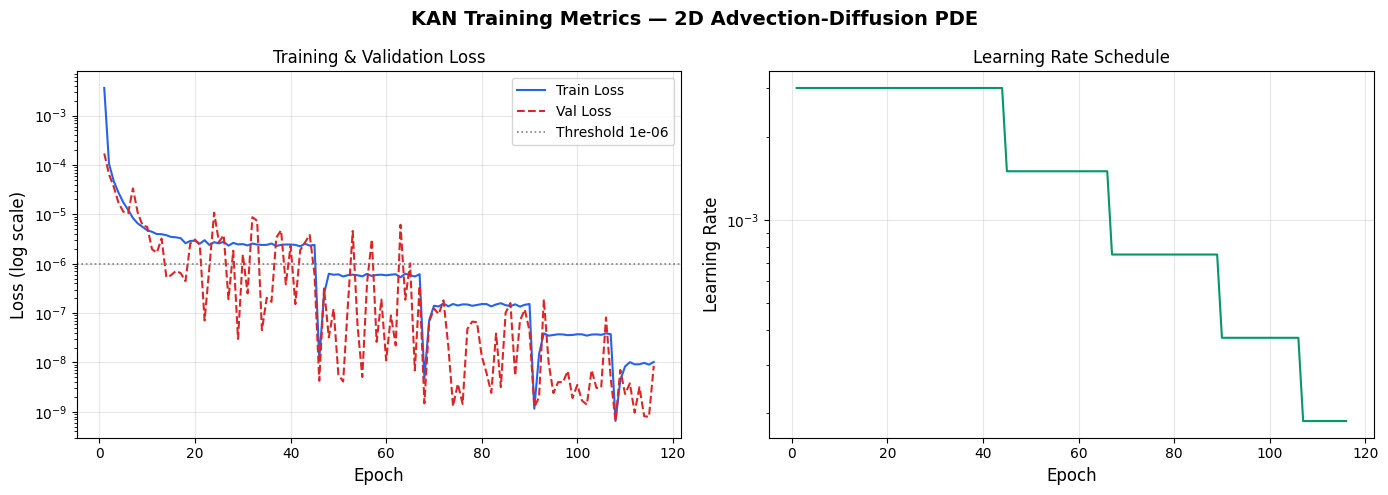

  -> saved KAN_01_training_metrics.png


In [9]:
ep_a_kan = np.arange(1, kan_final_epoch + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KAN Training Metrics — 2D Advection-Diffusion PDE',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_kan, kan_train_losses, lw=1.5, color='#2563EB', label='Train Loss')
ax.semilogy(ep_a_kan, kan_val_losses,   lw=1.5, color='#DC2626', ls='--', label='Val Loss')
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.2, label=f'Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Loss (log scale)', fontsize=FS)
ax.set_title('Training & Validation Loss')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(ep_a_kan, kan_lr_history, lw=1.5, color='#059669')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Learning Rate', fontsize=FS)
ax.set_title('Learning Rate Schedule')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('KAN_01_training_metrics.png')


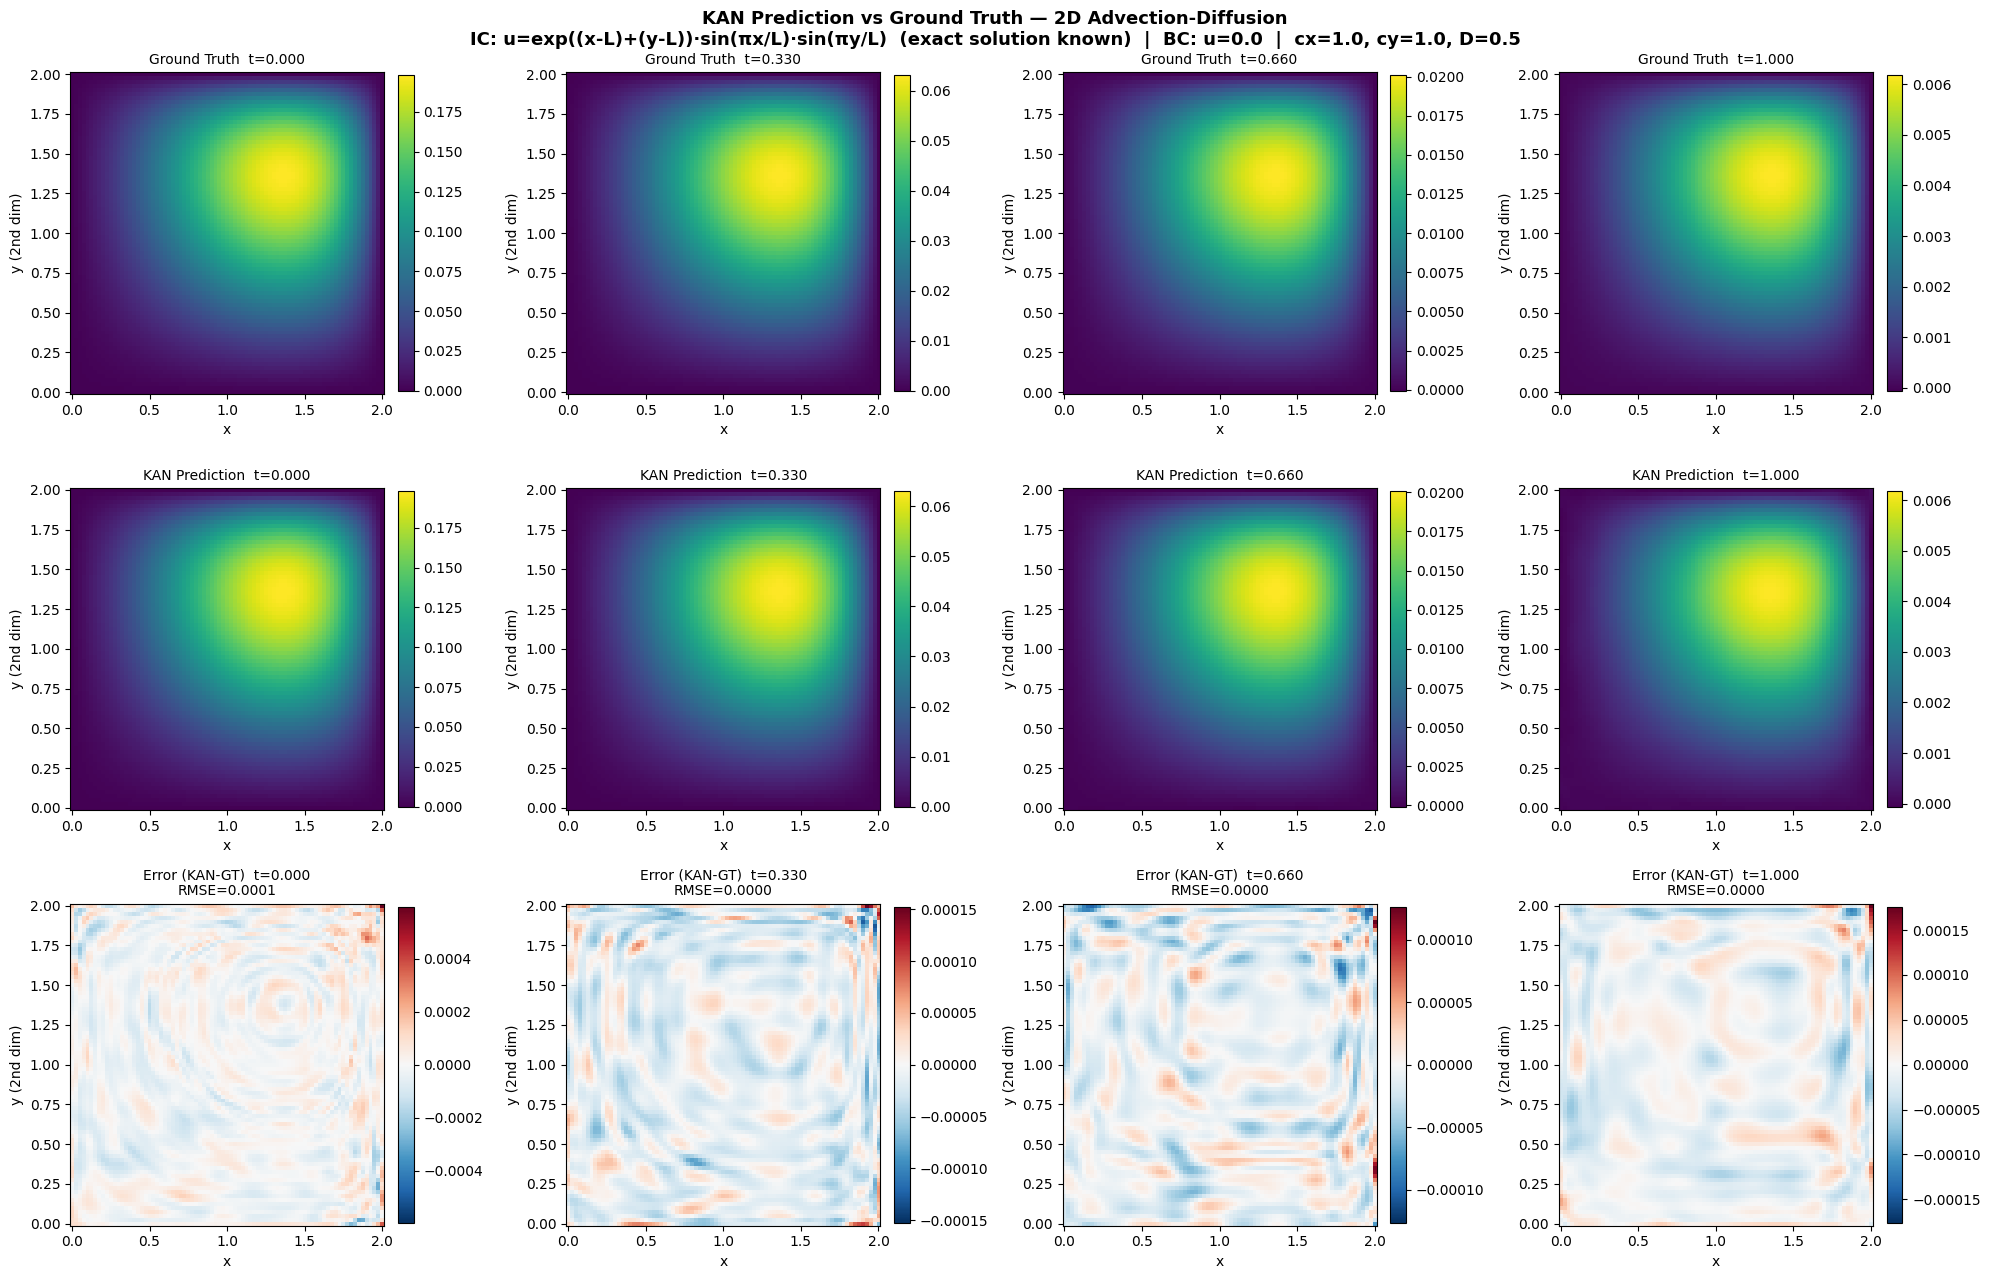

  -> saved KAN_02_snapshot_comparison.png


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'KAN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=exp((x-L)+(y-L))\u00b7sin(\u03c0x/L)\u00b7sin(\u03c0y/L)  (exact solution known)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk  = snap_t[si]
    Ugt = KAN_true_snaps[si]
    Ukn = KAN_pred_snaps[si]
    err = Ukn - Ugt
    vmin = min(Ugt.min(), Ukn.min()); vmax = max(Ugt.max(), Ukn.max())
    emax = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'KAN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_k = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (KAN-GT)  t={tk:.3f}\nRMSE={rmse_k:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('KAN_02_snapshot_comparison.png')

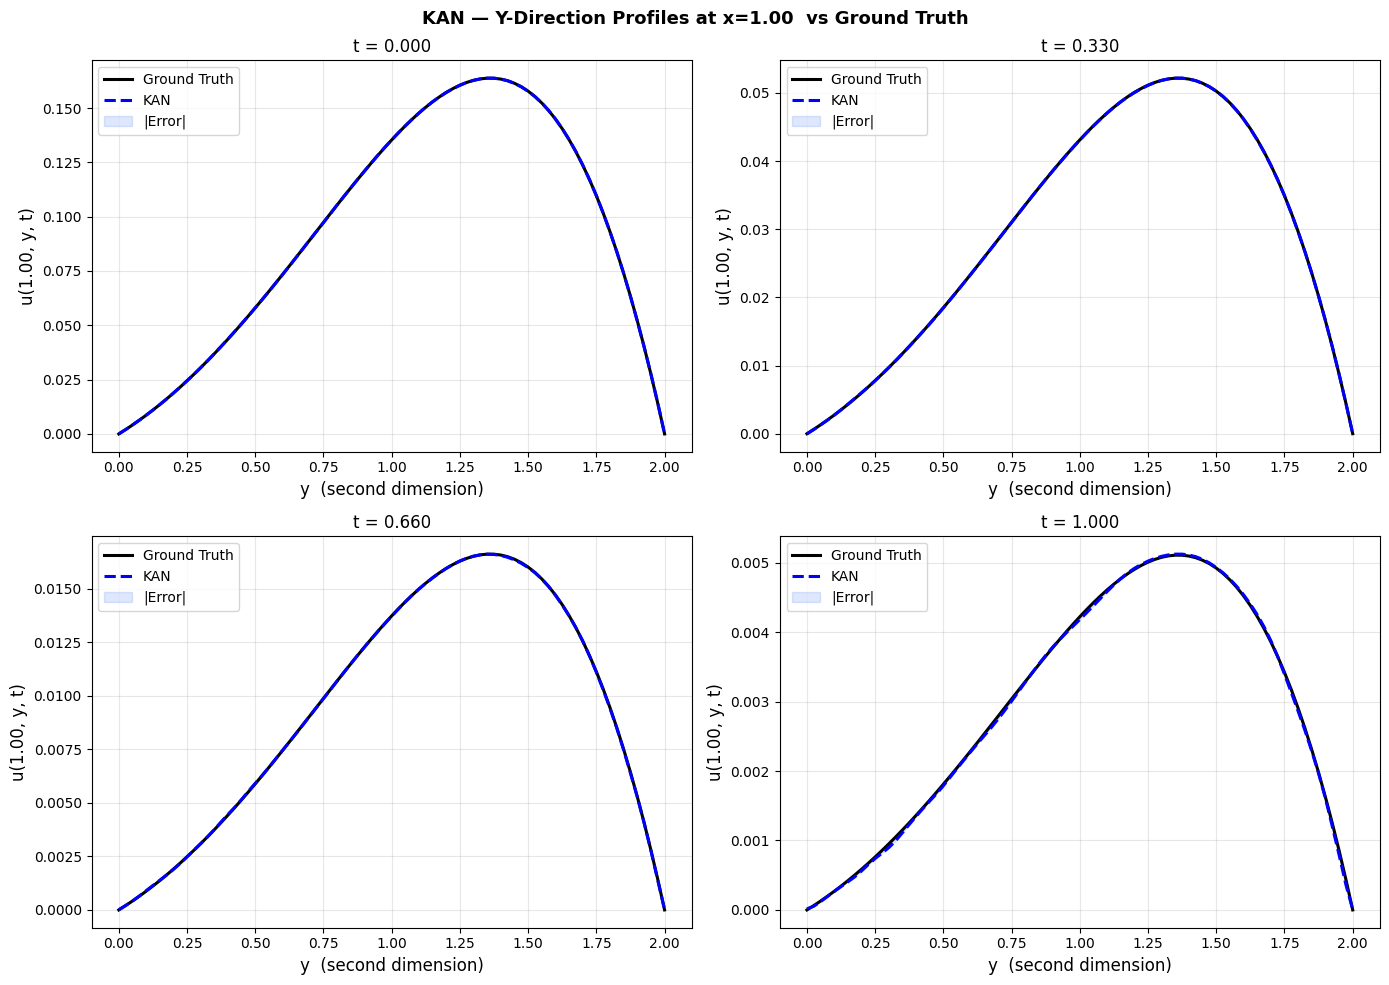

  -> saved KAN_03_y_profiles.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'KAN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    kn_y = KAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, kn_y, 'b--', lw=2.2, label='KAN')
    ax.fill_between(y_grid, gt_y, kn_y, alpha=0.15, color='#2563EB', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('KAN_03_y_profiles.png')

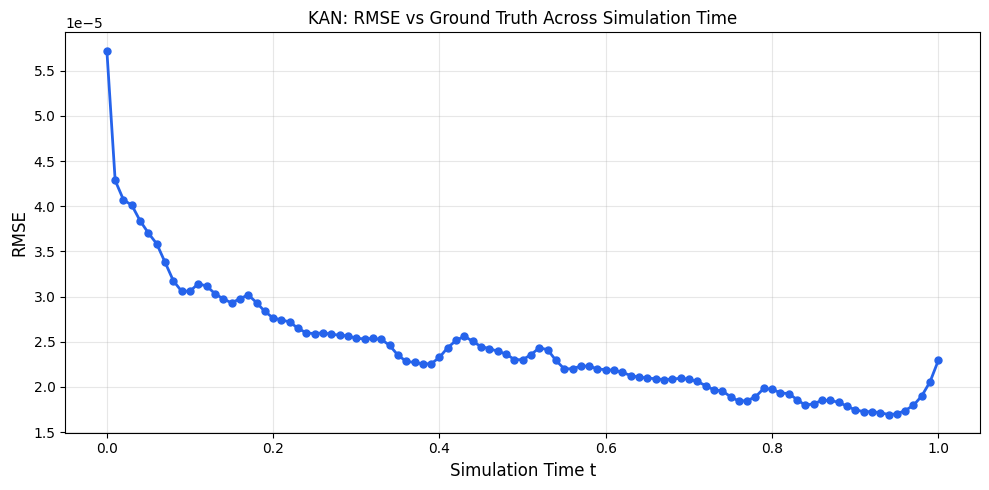

  -> saved KAN_04_rmse_over_time.png
KAN offloaded to CPU. GPU memory freed for PINN training.


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, kan_rmse_t, 'o-', color='#2563EB', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('KAN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('KAN_04_rmse_over_time.png')

# ── GPU memory: offload KAN to CPU before PINN training ──────────────────────
# KAN predictions and plots are complete; move weights to CPU RAM to free
# VRAM for the PINN (and later PIKAN) training.
kan_model.cpu()
torch.cuda.empty_cache()
print('KAN offloaded to CPU. GPU memory freed for PINN training.')

## 8. PINN Model Definition

In [13]:
class MLP(nn.Module):
    def __init__(self, width=128, depth=6):
        super().__init__()
        layers = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

pinn_model    = MLP().to(device)
pinn_n_params = sum(p.numel() for p in pinn_model.parameters())
print(f'PINN: MLP  width=128  depth=6  params={pinn_n_params:,}')
print(pinn_model)

PINN: MLP  width=128  depth=6  params=83,201
MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 9. PINN — Training

In [14]:
import gc

# ── Aggressive GPU memory cleanup before PINN ─────────────────────────────────
kan_model.cpu()
gc.collect()
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated(0) / 1e9
reserved  = torch.cuda.memory_reserved(0) / 1e9
print(f'GPU memory before PINN — allocated: {allocated:.2f} GiB | reserved: {reserved:.2f} GiB')

PINN_N_F            = 50000
PINN_N_IC           = 20000
PINN_N_BC           = 16000
PINN_EPOCHS_ADAM    = 20000
PINN_EPOCHS_LBFGS   = 500
PINN_LR             = 1e-3
PINN_PRINT_EVERY    = 1000
PINN_EARLY_THRESH   = 1e-6
PINN_EARLY_PATIENCE = 2000
PINN_MAX_WALL       = 7200.0
PINN_RESAMPLE_EVERY = 1000

PINN_W_F   = 1.0
PINN_W_IC  = 5.0
PINN_W_BC  = 1.0

def to_torch_pinn(a):
    return torch.tensor(a, dtype=torch.float32, device=device).view(-1, 1)

def sample_ic_pinn(n):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.zeros(n)
    c_ = ic_xy(x_, y_)
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn, c_

def sample_bc_pinn(n):
    n_each = n // 4
    tL = np.random.rand(n_each) * T;  yL = np.random.rand(n_each) * L;  xL = np.zeros(n_each)
    tR = np.random.rand(n_each) * T;  yR = np.random.rand(n_each) * L;  xR = np.ones(n_each) * L
    tB = np.random.rand(n_each) * T;  xB = np.random.rand(n_each) * L;  yB = np.zeros(n_each)
    tT = np.random.rand(n_each) * T;  xT = np.random.rand(n_each) * L;  yT = np.ones(n_each) * L
    x_ = np.concatenate([xL, xR, xB, xT])
    y_ = np.concatenate([yL, yR, yB, yT])
    t_ = np.concatenate([tL, tR, tB, tT])
    c_ = np.full(len(x_), BC_VAL, dtype=np.float32)
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn, c_

def sample_collocation_pinn(n):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.random.rand(n) * T
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn

xn_ic, yn_ic, tn_ic, c_ic = sample_ic_pinn(PINN_N_IC)
xn_bc, yn_bc, tn_bc, c_bc = sample_bc_pinn(PINN_N_BC)
xn_f,  yn_f,  tn_f        = sample_collocation_pinn(PINN_N_F)

X_ic_p = torch.cat([to_torch_pinn(tn_ic), to_torch_pinn(xn_ic), to_torch_pinn(yn_ic)], dim=1)
Y_ic_p = to_torch_pinn(c_ic)
X_bc_p = torch.cat([to_torch_pinn(tn_bc), to_torch_pinn(xn_bc), to_torch_pinn(yn_bc)], dim=1)
Y_bc_p = to_torch_pinn(c_bc)
X_f_p  = torch.cat([to_torch_pinn(tn_f),  to_torch_pinn(xn_f),  to_torch_pinn(yn_f )], dim=1)

print(f'PINN IC {X_ic_p.shape}  BC {X_bc_p.shape}  Collocation {X_f_p.shape}')

GPU memory before PINN — allocated: 0.03 GiB | reserved: 0.05 GiB
PINN IC torch.Size([20000, 3])  BC torch.Size([16000, 3])  Collocation torch.Size([50000, 3])


In [15]:
SCALE_X = 2.0 / L
SCALE_Y = 2.0 / L
SCALE_T = 2.0 / T

def pde_residual(forward_fn, X):
    """
    Pure physics residual for the 2D advection-diffusion PDE.
    Accepts any callable forward_fn(X) -> u so both PINN and PIKAN
    inherit the same physics without sharing state or wall clocks.
    """
    X = X.clone().requires_grad_(True)
    c = forward_fn(X)
    grads = torch.autograd.grad(c, X, torch.ones_like(c), create_graph=True)[0]
    dc_dtn = grads[:, 0:1]
    dc_dxn = grads[:, 1:2]
    dc_dyn = grads[:, 2:3]
    ct  = dc_dtn * SCALE_T
    cx  = dc_dxn * SCALE_X
    cy  = dc_dyn * SCALE_Y
    g2x = torch.autograd.grad(dc_dxn, X, torch.ones_like(dc_dxn), create_graph=True)[0]
    g2y = torch.autograd.grad(dc_dyn, X, torch.ones_like(dc_dyn), create_graph=True)[0]
    cxx = g2x[:, 1:2] * SCALE_X ** 2
    cyy = g2y[:, 2:3] * SCALE_Y ** 2
    return ct + CX * cx + CY * cy - D * (cxx + cyy)

# PINN total loss — pinn_model passed directly (no lambda, avoids per-call closure overhead)
def pinn_total_loss():
    loss_ic = ((pinn_model(X_ic_p) - Y_ic_p) ** 2).mean()
    loss_bc = ((pinn_model(X_bc_p) - Y_bc_p) ** 2).mean()
    loss_f  = (pde_residual(pinn_model, X_f_p) ** 2).mean()  # pass model directly — no lambda needed
    return PINN_W_F * loss_f + PINN_W_IC * loss_ic + PINN_W_BC * loss_bc, loss_f, loss_ic, loss_bc

pinn_opt = torch.optim.Adam(pinn_model.parameters(), lr=PINN_LR)
pinn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    pinn_opt, mode='min', patience=15, factor=0.5, min_lr=5e-6
)

# ── Resume from checkpoint if available ──────────────────────────────────────
_pinn_ckpt = load_ckpt('pinn')
if _pinn_ckpt is not None:
    pinn_model.load_state_dict(_pinn_ckpt['model_state'])
    pinn_model.to(device)
    pinn_loss_hist   = _pinn_ckpt['loss_hist']
    pinn_lr_history  = _pinn_ckpt['lr_history']
    pinn_best_loss   = _pinn_ckpt['best_loss']
    pinn_no_improve  = _pinn_ckpt['no_improve']
    pinn_stop_reason = _pinn_ckpt['stop_reason']
    _pinn_start_epoch = _pinn_ckpt['epoch'] + 1
    pinn_train_start = time.time()
    print(f'PINN resumed from epoch {_pinn_ckpt["epoch"]}  best_loss={pinn_best_loss:.4e}')
else:
    pinn_loss_hist   = []
    pinn_lr_history  = []
    pinn_best_loss   = float('inf')
    pinn_no_improve  = 0
    pinn_stop_reason = 'completed Adam epochs'
    _pinn_start_epoch = 1
    pinn_train_start = time.time()

print('PINN Phase 1: Adam')
print(f'{"Epoch":>7} | {"total":>10} | {"pde":>10} | {"ic":>10} | {"bc":>10} | {"lr":>9} | {"wall":>7}')
print('-' * 75)

for epoch in range(_pinn_start_epoch, PINN_EPOCHS_ADAM + 1):
    elapsed = time.time() - pinn_train_start
    if elapsed >= PINN_MAX_WALL:
        pinn_stop_reason = f'2-hour wall-clock limit at Adam epoch {epoch}'; break

    if epoch > 1 and (epoch - 1) % PINN_RESAMPLE_EVERY == 0:
        xn_f, yn_f, tn_f = sample_collocation_pinn(PINN_N_F)
        X_f_p = torch.cat([to_torch_pinn(tn_f), to_torch_pinn(xn_f), to_torch_pinn(yn_f)], dim=1)

    pinn_opt.zero_grad()
    loss, loss_f, loss_ic, loss_bc = pinn_total_loss()
    loss.backward()
    nn.utils.clip_grad_norm_(pinn_model.parameters(), 1.0)
    pinn_opt.step()

    lv     = loss.item()
    cur_lr = pinn_opt.param_groups[0]['lr']
    pinn_loss_hist.append([lv, loss_f.item(), loss_ic.item(), loss_bc.item()])
    pinn_lr_history.append(cur_lr)
    pinn_scheduler.step(lv)

    if pinn_best_loss - lv > PINN_EARLY_THRESH:
        pinn_best_loss  = lv
        pinn_no_improve = 0
    else:
        pinn_no_improve += 1

    if pinn_no_improve >= PINN_EARLY_PATIENCE:
        pinn_stop_reason = (f'early stop (Adam): no improvement > {PINN_EARLY_THRESH:.0e} '
                            f'for {PINN_EARLY_PATIENCE} epochs (epoch {epoch})')
        break

    if epoch % PINN_PRINT_EVERY == 0 or epoch == 1:
        print(f'{epoch:>7} | {lv:>10.3e} | {loss_f.item():>10.3e} | {loss_ic.item():>10.3e} '
              f'| {loss_bc.item():>10.3e} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

    # Save checkpoint every 1000 epochs
    if epoch % 1000 == 0:
        save_ckpt('pinn', {
            'epoch': epoch, 'model_state': {k: v.cpu().clone() for k, v in pinn_model.state_dict().items()},
            'loss_hist': pinn_loss_hist, 'lr_history': pinn_lr_history,
            'best_loss': pinn_best_loss, 'no_improve': pinn_no_improve,
            'stop_reason': pinn_stop_reason,
        })
        pinn_model.to(device)

pinn_adam_epochs = len(pinn_loss_hist)
print(f'\nAdam phase done: {pinn_adam_epochs} epochs  |  best loss {pinn_best_loss:.4e}')

print(f'\nPINN Phase 2: L-BFGS ({PINN_EPOCHS_LBFGS} steps)')
lbfgs_opt = torch.optim.LBFGS(
    pinn_model.parameters(),
    max_iter=20,
    history_size=50,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    line_search_fn='strong_wolfe'
)
lbfgs_loss_hist = []

_pinn_last = {}

def closure():
    lbfgs_opt.zero_grad()
    l, lf, li, lb = pinn_total_loss()
    l.backward()
    _pinn_last['lv'] = l.item()
    _pinn_last['lf'] = lf.item()
    _pinn_last['li'] = li.item()
    _pinn_last['lb'] = lb.item()
    return l

for step in range(1, PINN_EPOCHS_LBFGS + 1):
    if time.time() - pinn_train_start >= PINN_MAX_WALL:
        print('  L-BFGS: wall-clock limit reached'); break

    lbfgs_opt.step(closure)
    lv = _pinn_last['lv']
    lbfgs_loss_hist.append([lv, _pinn_last['lf'], _pinn_last['li'], _pinn_last['lb']])

    if step % 100 == 0 or step == 1:
        print(f'  L-BFGS step {step:4d} | total {lv:.3e} | pde {_pinn_last["lf"]:.3e} '
              f'| ic {_pinn_last["li"]:.3e} | bc {_pinn_last["lb"]:.3e}')

lbfgs_loss_hist  = np.array(lbfgs_loss_hist).reshape(-1, 4)
pinn_loss_hist   = np.array(pinn_loss_hist)
pinn_final_epoch = len(pinn_loss_hist)
pinn_total_time  = time.time() - pinn_train_start

print(f'\n>>> PINN Phase 1 (Adam) stopped: {pinn_stop_reason}')
if len(lbfgs_loss_hist):
    print(f'>>> Phase 2 (L-BFGS): {len(lbfgs_loss_hist)} steps  |  final loss {lbfgs_loss_hist[-1,0]:.4e}')
else:
    print('>>> Phase 2 (L-BFGS): 0 steps  |  (wall-clock limit reached)')
print(f'>>> Total PINN time: {pinn_total_time:.1f}s ({pinn_total_time/60:.2f} min)')
pinn_best_loss = min(pinn_loss_hist[:,0].min(),
                     lbfgs_loss_hist[:,0].min() if len(lbfgs_loss_hist) else float('inf'))
print(f'>>> Best overall loss: {pinn_best_loss:.4e}')

# Save final PINN checkpoint
save_ckpt('pinn_done', {
    'model_state': {k: v.cpu().clone() for k, v in pinn_model.state_dict().items()},
    'loss_hist': pinn_loss_hist, 'lbfgs_loss_hist': lbfgs_loss_hist,
    'lr_history': pinn_lr_history, 'best_loss': pinn_best_loss,
    'stop_reason': pinn_stop_reason, 'total_time': pinn_total_time,
})
pinn_model.to(device)


PINN Phase 1: Adam
  Epoch |      total |        pde |         ic |         bc |        lr |    wall
---------------------------------------------------------------------------
      1 |  2.630e-02 |  1.189e-03 |  4.440e-03 |  2.905e-03 |  1.00e-03 |   0.0s
   1000 |  1.647e-03 |  5.381e-04 |  1.732e-04 |  2.428e-04 |  5.00e-06 |  29.2s
  [ckpt] saved  -> pinn.pt
   2000 |  1.386e-03 |  4.577e-04 |  1.447e-04 |  2.045e-04 |  5.00e-06 |  58.2s
  [ckpt] saved  -> pinn.pt
   3000 |  1.133e-03 |  3.898e-04 |  1.165e-04 |  1.612e-04 |  5.00e-06 |  87.3s
  [ckpt] saved  -> pinn.pt
   4000 |  8.987e-04 |  3.448e-04 |  8.724e-05 |  1.177e-04 |  5.00e-06 | 116.4s
  [ckpt] saved  -> pinn.pt
   5000 |  6.561e-04 |  2.856e-04 |  5.796e-05 |  8.072e-05 |  5.00e-06 | 145.5s
  [ckpt] saved  -> pinn.pt
   6000 |  4.368e-04 |  2.072e-04 |  3.497e-05 |  5.471e-05 |  5.00e-06 | 174.6s
  [ckpt] saved  -> pinn.pt
   7000 |  2.750e-04 |  1.290e-04 |  2.092e-05 |  4.140e-05 |  5.00e-06 | 203.7s
  [ckpt] save

MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

## 10. PINN — Predictions & Metrics

In [16]:
@torch.no_grad()
def predict_on_grid(model, t_phys):
    Xg, Yg = np.meshgrid(x_sol, y_sol, indexing='xy')
    xn_g, yn_g, tn_g = normalise_inputs(Xg.ravel(), Yg.ravel(),
                                         np.full(Xg.size, t_phys))
    inp   = np.column_stack([tn_g, xn_g, yn_g]).astype(np.float32)
    inp_t = torch.tensor(inp, device=device)
    pred  = model(inp_t).detach().cpu().numpy().reshape(y_sol.size, x_sol.size)
    return pred

def rel_l2(a, b):
    return float(np.linalg.norm((a - b).ravel()) / (np.linalg.norm(b.ravel()) + 1e-12))

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

times_eval = [0.0, 0.25 * T, 0.5 * T, 0.75 * T, T]
pinn_metrics = []
for tt in times_eval:
    idx_t = int(round(tt / DT))
    gt    = C_gt[idx_t]
    pred  = predict_on_grid(pinn_model, t_sol[idx_t])
    pinn_metrics.append([t_sol[idx_t], rel_l2(pred, gt), mse_np(pred, gt)])

print('PINN Accuracy vs Ground Truth:')
print(f'  {"t":>6}  {"relL2":>10}  {"MSE":>12}')
for tt, rl2, ms in pinn_metrics:
    print(f'  {tt:6.3f}  {rl2:10.3e}  {ms:12.3e}')

PINN_pred_snaps = []
for tk in snap_t:
    pred_yx = predict_on_grid(pinn_model, tk)
    PINN_pred_snaps.append(pred_yx.T)
PINN_pred_snaps = np.array(PINN_pred_snaps)

pinn_rmse_t  = [np.sqrt(np.mean((PINN_pred_snaps[k] - KAN_true_snaps[k])**2))
                for k in range(len(snap_t))]
pinn_mse_eval = [m[2] for m in pinn_metrics]
pinn_rl2_eval = [m[1] for m in pinn_metrics]

# ── GPU memory: offload PINN to CPU before PIKAN training ────────────────────
# PINN predictions are complete; move weights to CPU RAM to free VRAM for PIKAN.
pinn_model.cpu()
torch.cuda.empty_cache()
print('PINN offloaded to CPU. GPU memory freed for PIKAN training.')

PINN Accuracy vs Ground Truth:
       t       relL2           MSE
   0.000   2.402e-02     4.290e-06
   0.250   5.675e-02     4.230e-06
   0.500   8.867e-02     1.824e-06
   0.750   1.595e-01     1.042e-06
   1.000   6.092e-01     2.687e-06
PINN offloaded to CPU. GPU memory freed for PIKAN training.


## 11. PINN — Plots

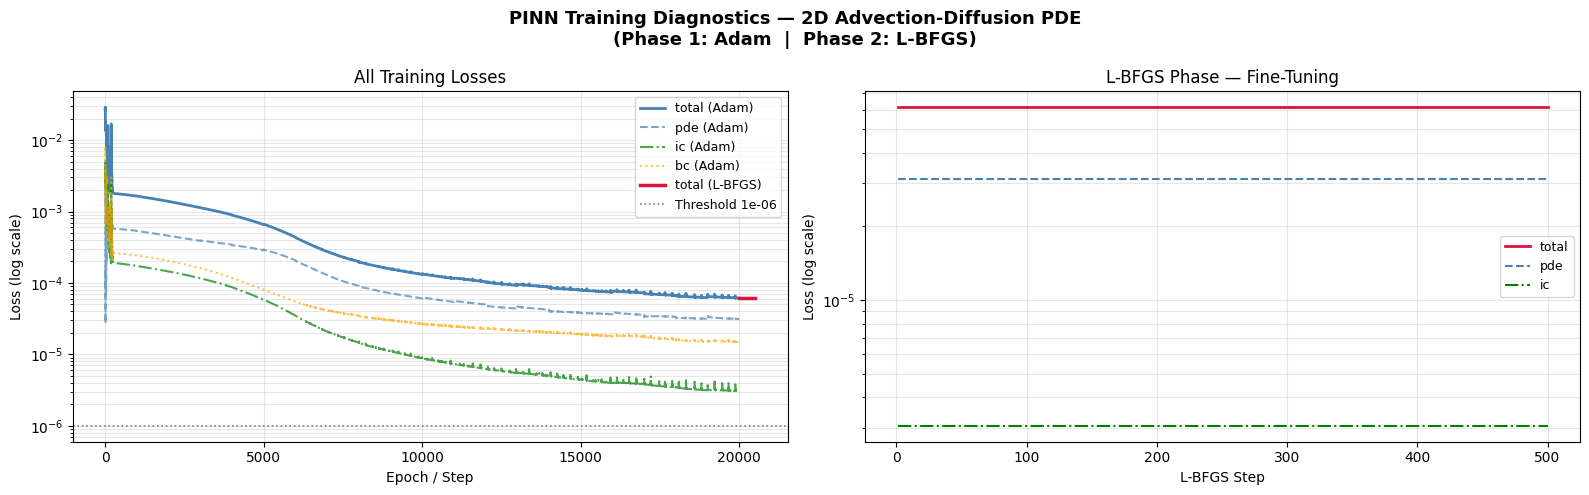

  -> saved PINN_01_training_metrics.png


In [17]:
ep_a_pinn = np.arange(1, pinn_final_epoch + 1)
ep_lbfgs  = np.arange(pinn_final_epoch + 1, pinn_final_epoch + 1 + len(lbfgs_loss_hist))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PINN Training Diagnostics — 2D Advection-Diffusion PDE\n'
             '(Phase 1: Adam  |  Phase 2: L-BFGS)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 0], label='total (Adam)',  linewidth=2,   color='steelblue')
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 1], label='pde (Adam)',   linewidth=1.5, color='steelblue', ls='--', alpha=0.7)
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 2], label='ic (Adam)',    linewidth=1.5, color='green',     ls='-.', alpha=0.7)
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 3], label='bc (Adam)',    linewidth=1.5, color='orange',    ls=':',  alpha=0.7)
if len(lbfgs_loss_hist):
    ax.semilogy(ep_lbfgs, lbfgs_loss_hist[:, 0], label='total (L-BFGS)', linewidth=2.5, color='crimson')
ax.axhline(PINN_EARLY_THRESH, color='gray', ls=':', lw=1.2, label=f'Threshold {PINN_EARLY_THRESH:.0e}')
ax.set_xlabel('Epoch / Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('All Training Losses'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
if len(lbfgs_loss_hist):
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 0],
                lw=2, color='crimson', label='total')
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 1],
                lw=1.5, color='steelblue', ls='--', label='pde')
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 2],
                lw=1.5, color='green', ls='-.', label='ic')
ax.set_xlabel('L-BFGS Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('L-BFGS Phase — Fine-Tuning'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
save_and_show('PINN_01_training_metrics.png')

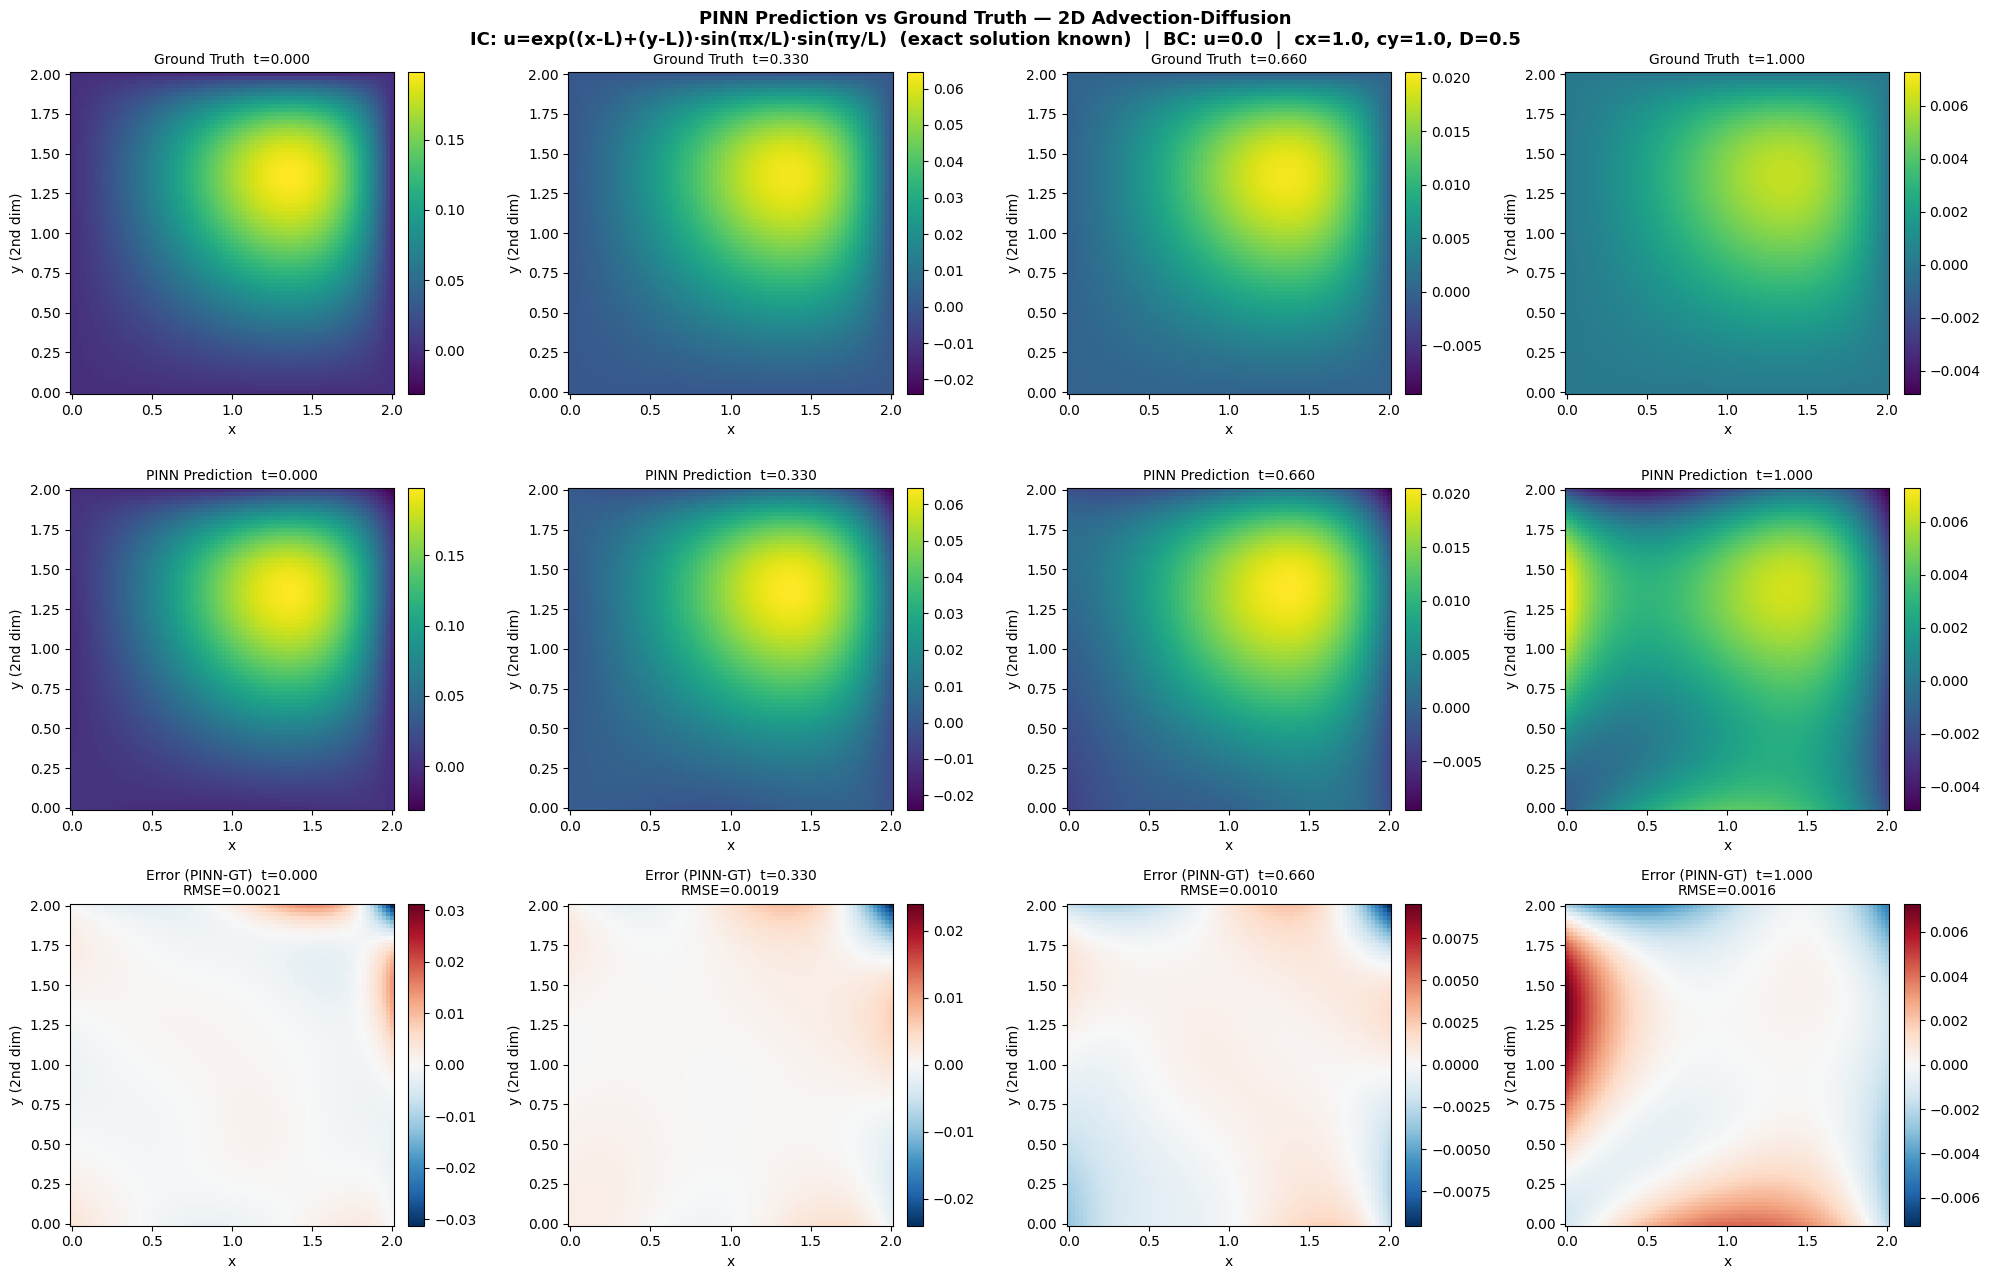

  -> saved PINN_02_snapshot_comparison.png


In [18]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'PINN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=exp((x-L)+(y-L))\u00b7sin(\u03c0x/L)\u00b7sin(\u03c0y/L)  (exact solution known)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Upinn = PINN_pred_snaps[si]
    err   = Upinn - Ugt
    vmin  = min(Ugt.min(), Upinn.min()); vmax = max(Ugt.max(), Upinn.max())
    emax  = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Upinn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'PINN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_p = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (PINN-GT)  t={tk:.3f}\nRMSE={rmse_p:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('PINN_02_snapshot_comparison.png')

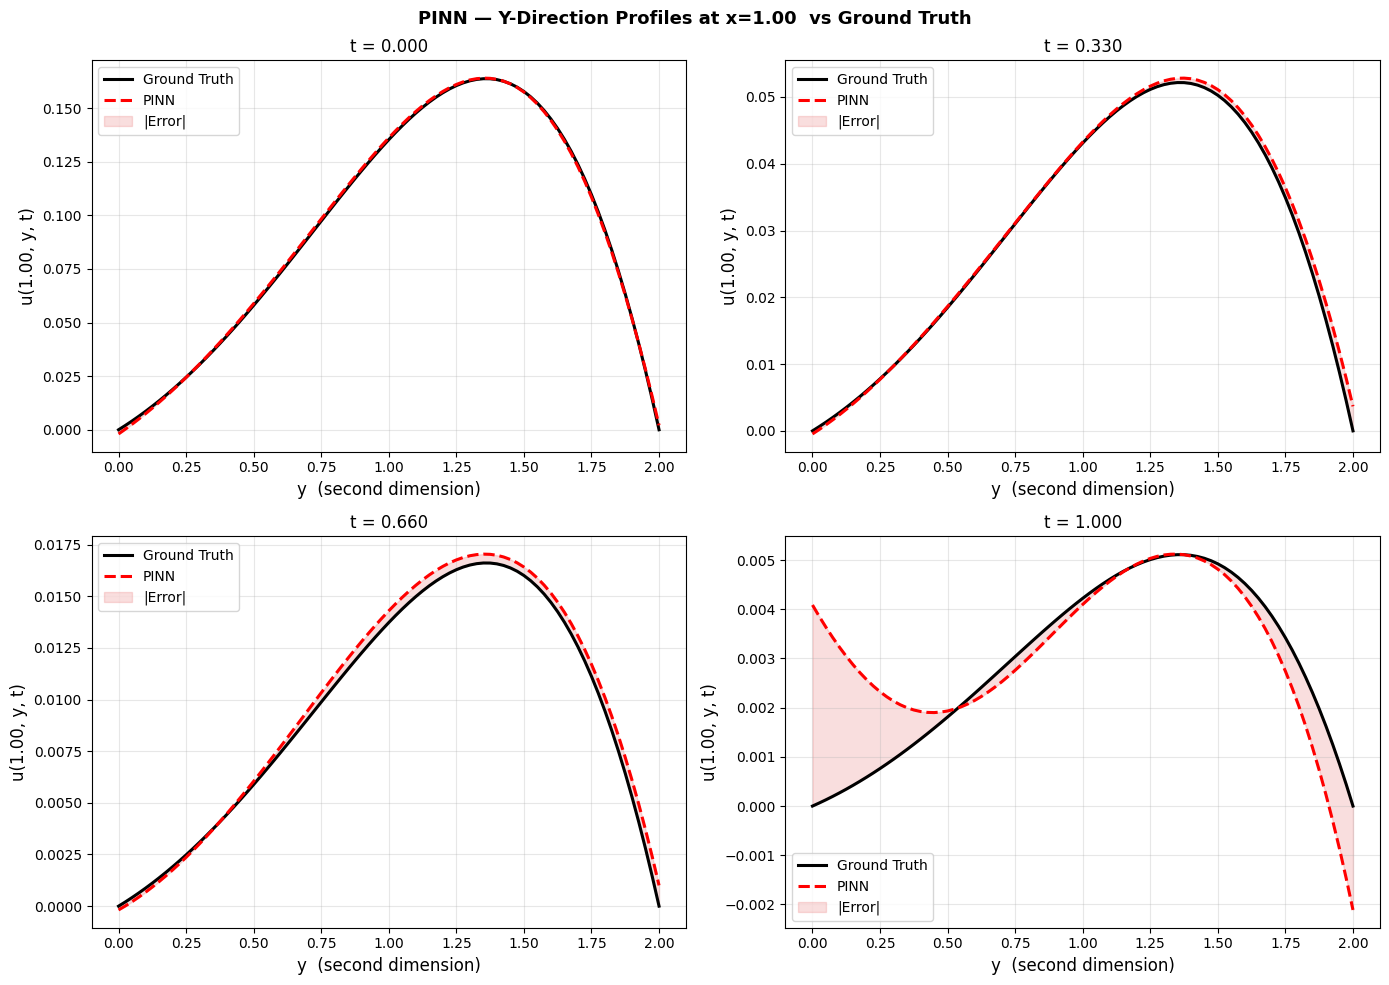

  -> saved PINN_03_y_profiles.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'PINN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    pn_y = PINN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, pn_y, 'r--', lw=2.2, label='PINN')
    ax.fill_between(y_grid, gt_y, pn_y, alpha=0.15, color='#DC2626', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('PINN_03_y_profiles.png')

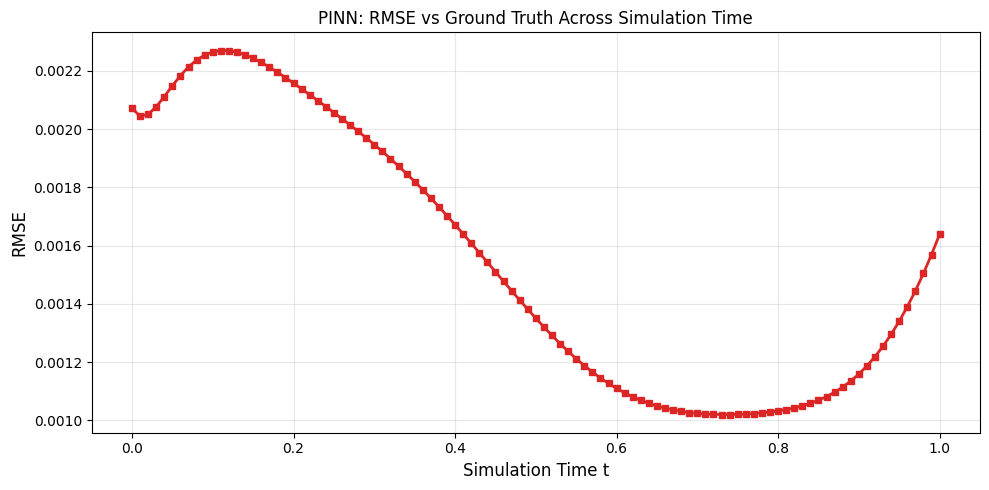

  -> saved PINN_04_rmse_over_time.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, pinn_rmse_t, 's-', color='#DC2626', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('PINN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('PINN_04_rmse_over_time.png')

## 12. PIKAN Model Definition

In [21]:
class PIKAN(nn.Module):
    """
    Cubic B-spline KAN with tanh between layers (see v4 notes). Input: [t, x, y] in [-1, 1].

    v6, hard=True: the IC and the zero BC are built into the output,
        u(t, x, y) = u0(x, y) + tau * (1 - x^2)(1 - y^2) * KAN(t, x, y),   tau = (t_n + 1)/2 = t/T
    so u = u0 at t = 0 and u = 0 on the boundary exactly, for any network weights.
    This works because u0 itself vanishes on the boundary (compatible IC/BC).
    """
    def __init__(self, widths=(3, 32, 32, 32, 1), grid_size=8, spline_order=3, hard=True):
        super().__init__()
        self.kan  = KAN(list(widths), grid_size, spline_order, smooth=False, norm='tanh')
        self.hard = hard

    def forward(self, X):
        N = self.kan(X)
        if not self.hard:
            return N
        tn, xn, yn = X[:, 0:1], X[:, 1:2], X[:, 2:3]
        x, y = (xn + 1) * L / 2, (yn + 1) * L / 2
        u0   = exact_solution_torch(x, y, 0.0)
        tau  = (tn + 1) / 2
        return u0 + tau * (1 - xn**2) * (1 - yn**2) * N

PIKAN_HARD = True
torch.manual_seed(42)
pikan_model    = PIKAN(hard=PIKAN_HARD).to(device)
pikan_n_params = sum(p.numel() for p in pikan_model.parameters())
print(f'PIKAN: KAN[3,32,32,32,1]  grid=8  order=3  params={pikan_n_params:,}  '
      f'basis=cubic B-spline, tanh between layers  |  hard IC/BC: {PIKAN_HARD}')


PIKAN: KAN[3,32,32,32,1]  grid=8  order=3  params=26,112  basis=cubic B-spline, tanh between layers  |  hard IC/BC: True


## 13. PIKAN — Training (v6)

With the built-in IC and BC (`PIKAN_HARD = True`) and `PIKAN_USE_DATA = False` (the default), the loss is **only the PDE residual**:

```
L = mean( (u_t + c_x u_x + c_y u_y − D Δu)² )   on fresh random collocation points every step
```

* The IC and BC losses are still logged as a sanity check; they should stay at about 0.
* Set `PIKAN_USE_DATA = True` to add supervised data sampled from the exact solution. The weights are then balanced by gradient norm, as in v4/v5.
* **Model selection:** relative L2 error against the exact solution on the held-out snapshots.
* L-BFGS polish is optional (`PIKAN_LBFGS_STEPS`). With a pure PDE loss it is worth trying; in v4 it hurt because it over-fitted a fixed data batch.


In [22]:
import gc, os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Free VRAM: KAN and PINN are finished and only needed again for the comparison plots.
kan_model.cpu()
pinn_model.cpu()
for _var in ['X_f_p', 'X_ic_p', 'X_bc_p', 'Y_ic_p', 'Y_bc_p',
             'X_tr', 'y_tr', 'X_va', 'y_va',
             'pinn_loss_hist', 'lbfgs_loss_hist',
             'kan_train_losses', 'kan_val_losses']:
    globals().pop(_var, None)
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f'GPU memory before PIKAN — allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GiB '
          f'| reserved: {torch.cuda.memory_reserved(0)/1e9:.2f} GiB')

# ════════════════════════════════════════════════════════════════════════════════
# PIKAN HYPERPARAMETERS — v6
# ════════════════════════════════════════════════════════════════════════════════
PIKAN_USE_DATA        = False    # v6 default: physics only. The exact solution is used for validation, not training
PIKAN_LR              = 1e-3
PIKAN_LR_MIN          = 1e-5
PIKAN_PRETRAIN_STEPS  = 3000     # data-only warm start (skipped if PIKAN_USE_DATA=False)
PIKAN_JOINT_STEPS     = 40000    # data + PDE + IC + BC, adaptive weights
PIKAN_LBFGS_STEPS     = 0        # v4 run: L-BFGS on a fixed batch raised held-out error 1.3e-3 -> 2.5e-3
PIKAN_MAX_WALL        = 30800.0  # ~8.5 h

# Minibatch sizes (one random minibatch of each per optimiser step)
# Scaled to GPU memory: the double-backward PDE residual through the KAN needs
# roughly 0.3 MB per collocation point.  A100 40/80 GB -> 32k, L4 24 GB -> 16k.
if device.type == 'cuda' and GPU_MEM_GB >= 38:
    PIKAN_DATA_BS, PIKAN_COLL_BS, PIKAN_IC_BS, PIKAN_BC_BS = 16384, 32768, 8192, 8192
else:
    PIKAN_DATA_BS, PIKAN_COLL_BS, PIKAN_IC_BS, PIKAN_BC_BS = 8192, 16384, 4096, 4096
# v5: fresh collocation points every step (drawn on the GPU). In v4 a 200k pool was
# redrawn every 2000 steps and the PDE loss jumped ~5x (up to ~400x) on each redraw:
# the model was over-fitting the pool.
PIKAN_EARLY_FRAC      = 0.25     # fraction of collocation points with t < PIKAN_EARLY_T
PIKAN_EARLY_T         = 0.1      # the IC/BC boundary layer lives here; most residual error too

# Adaptive loss balancing (gradient-norm balancing, Wang et al. 2023):
#   lambda_i = sum_j ||grad L_j|| / ||grad L_i||, EMA-smoothed
PIKAN_ADAPT_EVERY     = 100
PIKAN_ADAPT_ALPHA     = 0.9
PIKAN_W_MIN, PIKAN_W_MAX = 1e-3, 1e5

PIKAN_GRAD_CLIP_NORM  = 1.0
PIKAN_EVAL_EVERY      = 500      # validation on held-out snapshots
PIKAN_VAL_PATIENCE    = 30       # evaluations without improvement before early stop
PIKAN_PRINT_EVERY     = 1000
PIKAN_CKPT_EVERY      = 2000

# ── IC / BC points (column order [t, x, y], same as PINN and pde_residual) ─────────
PIKAN_N_IC = PINN_N_IC
PIKAN_N_BC = PINN_N_BC
xn_ic_pk, yn_ic_pk, tn_ic_pk, c_ic_pk = sample_ic_pinn(PIKAN_N_IC)
xn_bc_pk, yn_bc_pk, tn_bc_pk, c_bc_pk = sample_bc_pinn(PIKAN_N_BC)
X_ic_pk = torch.cat([to_torch_pinn(tn_ic_pk), to_torch_pinn(xn_ic_pk), to_torch_pinn(yn_ic_pk)], dim=1)
Y_ic_pk = to_torch_pinn(c_ic_pk)
X_bc_pk = torch.cat([to_torch_pinn(tn_bc_pk), to_torch_pinn(xn_bc_pk), to_torch_pinn(yn_bc_pk)], dim=1)
Y_bc_pk = to_torch_pinn(c_bc_pk)

def sample_colloc_gpu(n):
    """Fresh collocation points [t, x, y] in [-1, 1]^3, with PIKAN_EARLY_FRAC of them at t < PIKAN_EARLY_T."""
    X = torch.rand(n, 3, device=device) * 2 - 1
    n_early = int(PIKAN_EARLY_FRAC * n)
    X[:n_early, 0] = torch.rand(n_early, device=device) * (2 * PIKAN_EARLY_T / T) - 1
    return X

# ── GT data: FIX column order. inputs_kan_n is [x, y, t]; PIKAN expects [t, x, y] ──
_npts   = (Nx + 1) * (Ny + 1)
_n_snap = len(snap_t)
X_all_pk = inputs_kan_n[:, [2, 0, 1]].copy()
assert np.allclose(X_all_pk[:_npts, 0], -1.0), 'column reorder failed: first snapshot should have t_n = -1'

snap_id_pk       = np.repeat(np.arange(_n_snap), _npts)
holdout_snaps_pk = holdout_snaps          # same held-out snapshots as KAN (cell 12)
train_mask_pk    = ~np.isin(snap_id_pk, holdout_snaps_pk)

X_data_pk = torch.from_numpy(X_all_pk[train_mask_pk]).to(device)
Y_data_pk = torch.from_numpy(targets_kan[train_mask_pk]).unsqueeze(1).to(device)
X_hold_pk = torch.from_numpy(X_all_pk[~train_mask_pk]).to(device)
Y_hold_pk = torch.from_numpy(targets_kan[~train_mask_pk]).unsqueeze(1).to(device)

print(f'PIKAN IC {tuple(X_ic_pk.shape)}  BC {tuple(X_bc_pk.shape)}  collocation: {PIKAN_COLL_BS} fresh points/step '
      f'({PIKAN_EARLY_FRAC:.0%} at t < {PIKAN_EARLY_T})')
print(f'PIKAN data (train snapshots) {tuple(X_data_pk.shape)}  |  held-out {tuple(X_hold_pk.shape)} '
      f'({len(holdout_snaps_pk)} snapshots, t = {snap_t[holdout_snaps_pk[0]]:.3f}, '
      f'{snap_t[holdout_snaps_pk[1]]:.3f}, ...)')
print(f'Mode: {"data + physics" if PIKAN_USE_DATA else "physics only"}  |  '
      f'batch: data {PIKAN_DATA_BS}, collocation {PIKAN_COLL_BS}, IC/BC {PIKAN_IC_BS}')


GPU memory before PIKAN — allocated: 0.03 GiB | reserved: 0.05 GiB
PIKAN IC (20000, 3)  BC (16000, 3)  collocation: 32768 fresh points/step (25% at t < 0.1)
PIKAN data (train snapshots) (531441, 3)  |  held-out (131220, 3) (20 snapshots, t = 0.020, 0.070, ...)
Mode: physics only  |  batch: data 16384, collocation 32768, IC/BC 8192


In [23]:
import copy

# ════════════════════════════════════════════════════════════════════════════════
# PIKAN TRAINING — v6
#   Phase 1  data-only warm start (Adam, minibatch)
#   Phase 2  data + PDE + IC + BC with gradient-norm-balanced weights (Adam, minibatch)
#   Phase 3  L-BFGS polish on a fixed batch, weights frozen
# Model selection: relative L2 on held-out GT snapshots (never trained on).
# ════════════════════════════════════════════════════════════════════════════════
TERMS = ['data', 'pde', 'ic', 'bc']
_params = [p for p in pikan_model.parameters() if p.requires_grad]

def _mb(X, Y, bs):
    idx = torch.randint(0, X.shape[0], (min(bs, X.shape[0]),), device=X.device)
    return X[idx], (None if Y is None else Y[idx])

def pikan_loss_terms(Xd, Yd, Xf, Xi, Yi, Xb, Yb):
    zero = torch.zeros((), device=device)
    l_d = ((pikan_model(Xd) - Yd) ** 2).mean() if Xd is not None else zero
    l_f = (pde_residual(pikan_model, Xf) ** 2).mean() if Xf is not None else zero
    l_i = ((pikan_model(Xi) - Yi) ** 2).mean() if Xi is not None else zero
    l_b = ((pikan_model(Xb) - Yb) ** 2).mean() if Xb is not None else zero
    return {'data': l_d, 'pde': l_f, 'ic': l_i, 'bc': l_b}

def sample_batch(with_physics=True):
    Xd, Yd = _mb(X_data_pk, Y_data_pk, PIKAN_DATA_BS) if PIKAN_USE_DATA else (None, None)
    if not with_physics:
        return Xd, Yd, None, None, None, None, None
    Xf     = sample_colloc_gpu(PIKAN_COLL_BS)
    Xi, Yi = _mb(X_ic_pk, Y_ic_pk, PIKAN_IC_BS)
    Xb, Yb = _mb(X_bc_pk, Y_bc_pk, PIKAN_BC_BS)
    return Xd, Yd, Xf, Xi, Yi, Xb, Yb

def active_terms():
    keys = ['data'] if PIKAN_USE_DATA else []
    keys += ['pde'] if PIKAN_HARD else ['pde', 'ic', 'bc']   # hard IC/BC: those losses are identically ~0
    return keys

@torch.no_grad()
def pikan_val_rl2(chunk=32768):
    pikan_model.eval()
    num = den = 0.0
    for s in range(0, X_hold_pk.shape[0], chunk):
        p = pikan_model(X_hold_pk[s:s + chunk]); y = Y_hold_pk[s:s + chunk]
        num += ((p - y) ** 2).sum().item(); den += (y ** 2).sum().item()
    pikan_model.train()
    return (num / den) ** 0.5

def update_weights(losses, lam):
    norms = {}
    for k in active_terms():
        g = torch.autograd.grad(losses[k], _params, retain_graph=True, allow_unused=True)
        norms[k] = torch.sqrt(sum((gi ** 2).sum() for gi in g if gi is not None)).item() + 1e-12
    tot = sum(norms.values())
    for k in norms:
        new = min(max(tot / norms[k], PIKAN_W_MIN), PIKAN_W_MAX)
        lam[k] = PIKAN_ADAPT_ALPHA * lam[k] + (1 - PIKAN_ADAPT_ALPHA) * new
    return lam

# ── Optimiser, schedule, state (with resume) ───────────────────────────────────────
_n_pre   = PIKAN_PRETRAIN_STEPS if PIKAN_USE_DATA else 0
_n_adam  = _n_pre + PIKAN_JOINT_STEPS
pikan_opt = torch.optim.Adam(_params, lr=PIKAN_LR)
pikan_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(pikan_opt, T_max=_n_adam, eta_min=PIKAN_LR_MIN)

CKPT_NAME = 'pikan_v6'
_ck = load_ckpt(CKPT_NAME)
if _ck is not None:
    pikan_model.load_state_dict(_ck['model_state']); pikan_model.to(device)
    pikan_opt.load_state_dict(_ck['opt_state']); pikan_scheduler.load_state_dict(_ck['sched_state'])
    pikan_loss_hist, pikan_lr_history = _ck['loss_hist'], _ck['lr_history']
    pikan_val_hist, pikan_lambda_hist = _ck['val_hist'], _ck['lambda_hist']
    lam = _ck['lam']; pikan_best_val = _ck['best_val']; pikan_best_state = _ck['best_state']
    _bad_evals = _ck['bad_evals']; _start = _ck['step'] + 1; _elapsed0 = _ck['elapsed']
    print(f'PIKAN resumed at step {_start}  best held-out relL2 = {pikan_best_val:.3e}')
else:
    pikan_loss_hist, pikan_lr_history, pikan_val_hist, pikan_lambda_hist = [], [], [], []
    lam = {k: 1.0 for k in TERMS}
    pikan_best_val, pikan_best_state = float('inf'), None
    _bad_evals, _start, _elapsed0 = 0, 1, 0.0

pikan_stop_reason = 'completed all Adam steps'
pikan_train_start = time.time() - _elapsed0
pikan_model.train()

print(f'\n{"step":>7} | {"phase":>5} | {"total":>9} | {"data":>9} | {"pde":>9} | {"ic":>9} | {"bc":>9} '
      f'| {"val relL2":>9} | {"lr":>8} | {"wall":>7}')
print('-' * 110)

for step in range(_start, _n_adam + 1):
    elapsed = time.time() - pikan_train_start
    if elapsed >= PIKAN_MAX_WALL:
        pikan_stop_reason = f'wall-clock limit at step {step}'; break

    joint = step > _n_pre

    losses = pikan_loss_terms(*sample_batch(with_physics=joint))
    if joint and len(active_terms()) > 1 and (step - _n_pre - 1) % PIKAN_ADAPT_EVERY == 0:
        lam = update_weights(losses, lam)

    keys  = active_terms() if joint else ['data']
    total = sum(lam[k] * losses[k] for k in keys) if joint else losses['data']

    if not torch.isfinite(total):
        print(f'  non-finite loss at step {step}: restoring best state, halving LR')
        if pikan_best_state is not None:
            pikan_model.load_state_dict(pikan_best_state)
        for g in pikan_opt.param_groups: g['lr'] *= 0.5
        continue

    pikan_opt.zero_grad(set_to_none=True)
    total.backward()
    nn.utils.clip_grad_norm_(_params, PIKAN_GRAD_CLIP_NORM)
    pikan_opt.step()
    pikan_scheduler.step()

    pikan_loss_hist.append([total.item()] + [losses[k].item() for k in TERMS])
    pikan_lr_history.append(pikan_opt.param_groups[0]['lr'])
    pikan_lambda_hist.append([lam[k] for k in TERMS])

    if step % PIKAN_EVAL_EVERY == 0 or step == _n_adam:
        v = pikan_val_rl2()
        pikan_val_hist.append((step, v))
        if v < pikan_best_val:
            pikan_best_val = v
            pikan_best_state = copy.deepcopy(pikan_model.state_dict())
            _bad_evals = 0
        elif joint:
            _bad_evals += 1
    if step % PIKAN_PRINT_EVERY == 0 or step == 1 or step == _n_pre + 1:
        h = pikan_loss_hist[-1]
        vs = f'{pikan_val_hist[-1][1]:9.3e}' if pikan_val_hist else ' ' * 9
        print(f'{step:7d} | {"joint" if joint else "data":>5} | {h[0]:9.2e} | {h[1]:9.2e} | {h[2]:9.2e} | '
              f'{h[3]:9.2e} | {h[4]:9.2e} | {vs} | {pikan_lr_history[-1]:8.1e} | {elapsed:6.0f}s')
        if joint:
            print('          lambda: ' + '  '.join(f'{k}={lam[k]:.2e}' for k in active_terms()))

    if step % PIKAN_CKPT_EVERY == 0:
        save_ckpt(CKPT_NAME, {
            'step': step, 'model_state': pikan_model.state_dict(),
            'opt_state': pikan_opt.state_dict(), 'sched_state': pikan_scheduler.state_dict(),
            'loss_hist': pikan_loss_hist, 'lr_history': pikan_lr_history,
            'val_hist': pikan_val_hist, 'lambda_hist': pikan_lambda_hist, 'lam': lam,
            'best_val': pikan_best_val, 'best_state': pikan_best_state,
            'bad_evals': _bad_evals, 'elapsed': time.time() - pikan_train_start,
        })

    if _bad_evals >= PIKAN_VAL_PATIENCE:
        pikan_stop_reason = f'early stop: held-out error flat for {PIKAN_VAL_PATIENCE} evaluations (step {step})'
        break

print(f'\nAdam finished: {pikan_stop_reason}  |  best held-out relL2 = {pikan_best_val:.3e}')

# ── Phase 3: L-BFGS polish from the best Adam state ────────────────────────────────
pikan_lbfgs_hist = []
if pikan_best_state is not None:
    pikan_model.load_state_dict(pikan_best_state)

if PIKAN_LBFGS_STEPS > 0 and time.time() - pikan_train_start < PIKAN_MAX_WALL:
    torch.manual_seed(123)
    _fixed = sample_batch(with_physics=True)
    _lam_fixed = dict(lam)
    lbfgs = torch.optim.LBFGS(_params, lr=1.0, max_iter=20, history_size=50,
                              tolerance_grad=1e-9, tolerance_change=1e-12,
                              line_search_fn='strong_wolfe')
    _last = {}
    def _closure():
        lbfgs.zero_grad(set_to_none=True)
        ls = pikan_loss_terms(*_fixed)
        tot = sum(_lam_fixed[k] * ls[k] for k in active_terms())
        tot.backward()
        _last['h'] = [tot.item()] + [ls[k].item() for k in TERMS]
        return tot

    print(f'\nPhase 3: L-BFGS ({PIKAN_LBFGS_STEPS} outer steps, fixed batch, frozen weights)')
    for s in range(1, PIKAN_LBFGS_STEPS + 1):
        if time.time() - pikan_train_start >= PIKAN_MAX_WALL:
            print('  L-BFGS: wall-clock limit reached'); break
        lbfgs.step(_closure)
        if not np.isfinite(_last['h'][0]):
            print(f'  L-BFGS diverged at step {s}; reverting to best state'); break
        pikan_lbfgs_hist.append(_last['h'])
        if s % 20 == 0 or s == PIKAN_LBFGS_STEPS:
            v = pikan_val_rl2()
            pikan_val_hist.append((_n_adam + s, v))
            print(f'  L-BFGS {s:4d} | total {_last["h"][0]:.3e} | pde {_last["h"][2]:.3e} | val relL2 {v:.3e}')
            if v < pikan_best_val:
                pikan_best_val = v
                pikan_best_state = copy.deepcopy(pikan_model.state_dict())

# Always finish on the best model by held-out error
if pikan_best_state is not None:
    pikan_model.load_state_dict(pikan_best_state)
pikan_model.eval()

pikan_loss_hist_np = np.array(pikan_loss_hist)
pikan_lbfgs_hist   = np.array(pikan_lbfgs_hist).reshape(-1, 5)
pikan_best_loss    = float(pikan_loss_hist_np[:, 0].min()) if len(pikan_loss_hist_np) else float('nan')
pikan_final_epoch  = len(pikan_loss_hist)
pikan_total_time   = time.time() - pikan_train_start

print(f'\n>>> PIKAN stop reason         : {pikan_stop_reason}')
print(f'>>> Adam steps / L-BFGS steps  : {pikan_final_epoch} / {len(pikan_lbfgs_hist)}')
print(f'>>> Best held-out relative L2  : {pikan_best_val:.3e}')
print(f'>>> Total time                 : {pikan_total_time:.0f}s ({pikan_total_time/60:.1f} min)')
if device.type == 'cuda':
    print(f'>>> Peak GPU memory            : {torch.cuda.max_memory_allocated(0)/1e9:.1f} GB of {GPU_MEM_GB:.0f} GB')

save_ckpt('pikan_done', {
    'model_state': {k: v.cpu().clone() for k, v in pikan_model.state_dict().items()},
    'loss_hist': pikan_loss_hist_np, 'lbfgs_hist': pikan_lbfgs_hist,
    'lr_history': pikan_lr_history, 'val_hist': pikan_val_hist,
    'lambda_hist': pikan_lambda_hist, 'best_loss': pikan_best_loss,
    'best_val_rl2': pikan_best_val, 'stop_reason': pikan_stop_reason,
    'total_time': pikan_total_time,
})



   step | phase |     total |      data |       pde |        ic |        bc | val relL2 |       lr |    wall
--------------------------------------------------------------------------------------------------------------
      1 | joint |  3.46e+01 |  0.00e+00 |  3.46e+01 |  4.21e-16 |  3.37e-16 |           |  1.0e-03 |      0s
          lambda: pde=1.00e+00
   1000 | joint |  7.78e-05 |  0.00e+00 |  7.78e-05 |  4.20e-16 |  3.46e-16 | 4.079e-03 |  1.0e-03 |    159s
          lambda: pde=1.00e+00
   2000 | joint |  2.51e-05 |  0.00e+00 |  2.51e-05 |  4.15e-16 |  3.36e-16 | 1.600e-02 |  9.9e-04 |    319s
          lambda: pde=1.00e+00
  [ckpt] saved  -> pikan_v6.pt
   3000 | joint |  1.25e-05 |  0.00e+00 |  1.25e-05 |  4.40e-16 |  3.33e-16 | 1.261e-02 |  9.9e-04 |    478s
          lambda: pde=1.00e+00
   4000 | joint |  5.58e-06 |  0.00e+00 |  5.58e-06 |  4.22e-16 |  3.33e-16 | 3.766e-03 |  9.8e-04 |    637s
          lambda: pde=1.00e+00
  [ckpt] saved  -> pikan_v6.pt
   5000 | joint |

## 14. PIKAN — Predictions & Metrics

In [24]:
pikan_metrics = []
for tt in times_eval:
    idx_t = int(round(tt / DT))
    gt    = C_gt[idx_t]
    pred  = predict_on_grid(pikan_model, t_sol[idx_t])
    pikan_metrics.append([t_sol[idx_t], rel_l2(pred, gt), mse_np(pred, gt)])

print(f'PIKAN held-out snapshots ({len(holdout_snaps_pk)} never-trained times): '
      f'relative L2 = {pikan_val_rl2():.3e}')
print('PIKAN Accuracy vs Ground Truth (these times are in the training snapshots when PIKAN_USE_DATA=True):')
print(f'  {"t":>6}  {"relL2":>10}  {"MSE":>12}')
for tt, rl2, ms in pikan_metrics:
    print(f'  {tt:6.3f}  {rl2:10.3e}  {ms:12.3e}')

PIKAN_pred_snaps = []
for tk in snap_t:
    pred_yx = predict_on_grid(pikan_model, tk)
    PIKAN_pred_snaps.append(pred_yx.T)
PIKAN_pred_snaps = np.array(PIKAN_pred_snaps)

pikan_rmse_t  = [np.sqrt(np.mean((PIKAN_pred_snaps[k] - KAN_true_snaps[k])**2))
                 for k in range(len(snap_t))]
pikan_mse_eval = [m[2] for m in pikan_metrics]
pikan_rl2_eval = [m[1] for m in pikan_metrics]

PIKAN held-out snapshots (20 never-trained times): relative L2 = 5.729e-05
PIKAN Accuracy vs Ground Truth (these times are in the training snapshots when PIKAN_USE_DATA=True):
       t       relL2           MSE
   0.000   2.093e-07     3.259e-16
   0.250   5.262e-05     3.638e-12
   0.500   1.120e-04     2.910e-12
   0.750   3.920e-04     6.297e-12
   1.000   8.702e-04     5.482e-12


## 15. PIKAN — Plots

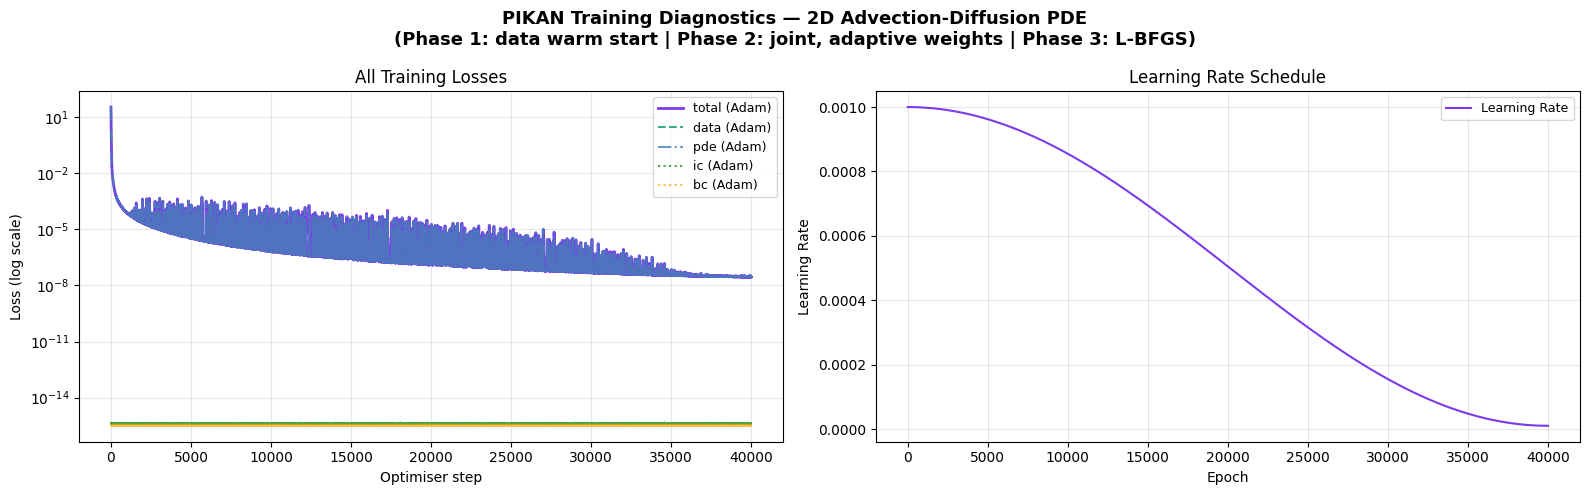

  -> saved PIKAN_01_training_metrics.png


In [25]:
pikan_final_epoch = len(pikan_loss_hist)
ep_a_pikan = np.arange(1, pikan_final_epoch + 1)
ep_lbfgs_pk = np.arange(pikan_final_epoch + 1, pikan_final_epoch + 1 + len(pikan_lbfgs_hist))

# Convert pikan_loss_hist to a NumPy array for easier indexing
pikan_loss_hist_np = np.array(pikan_loss_hist)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PIKAN Training Diagnostics — 2D Advection-Diffusion PDE\n'
             '(Phase 1: data warm start | Phase 2: joint, adaptive weights | Phase 3: L-BFGS)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 0], label='total (Adam)',  linewidth=2,   color='#7C3AED')
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 1], label='data (Adam)',   linewidth=1.5, color='#059669', ls='--', alpha=0.8)
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 2], label='pde (Adam)',    linewidth=1.5, color='steelblue', ls='-.', alpha=0.8)
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 3], label='ic (Adam)',     linewidth=1.5, color='green',   ls=':',  alpha=0.7)
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 4], label='bc (Adam)',     linewidth=1.5, color='orange',  ls=':',  alpha=0.7)
if len(pikan_lbfgs_hist):
    ax.semilogy(ep_lbfgs_pk, pikan_lbfgs_hist[:, 0], label='total (L-BFGS)', linewidth=2.5, color='crimson')
ax.set_xlabel('Optimiser step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('All Training Losses'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
if len(pikan_lbfgs_hist):
    ax.semilogy(np.arange(1, len(pikan_lbfgs_hist)+1), pikan_lbfgs_hist[:, 0],
                lw=2, color='crimson', label='total')
    ax.semilogy(np.arange(1, len(pikan_lbfgs_hist)+1), pikan_lbfgs_hist[:, 1],
                lw=1.5, color='#059669', ls='--', label='data')
    ax.semilogy(np.arange(1, len(pikan_lbfgs_hist)+1), pikan_lbfgs_hist[:, 2],
                lw=1.5, color='steelblue', ls='-.', label='pde')
else:
    ax.plot(pikan_lr_history, label='Learning Rate', color='#7C3AED')
    ax.set_title('Learning Rate Schedule')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
save_and_show('PIKAN_01_training_metrics.png')

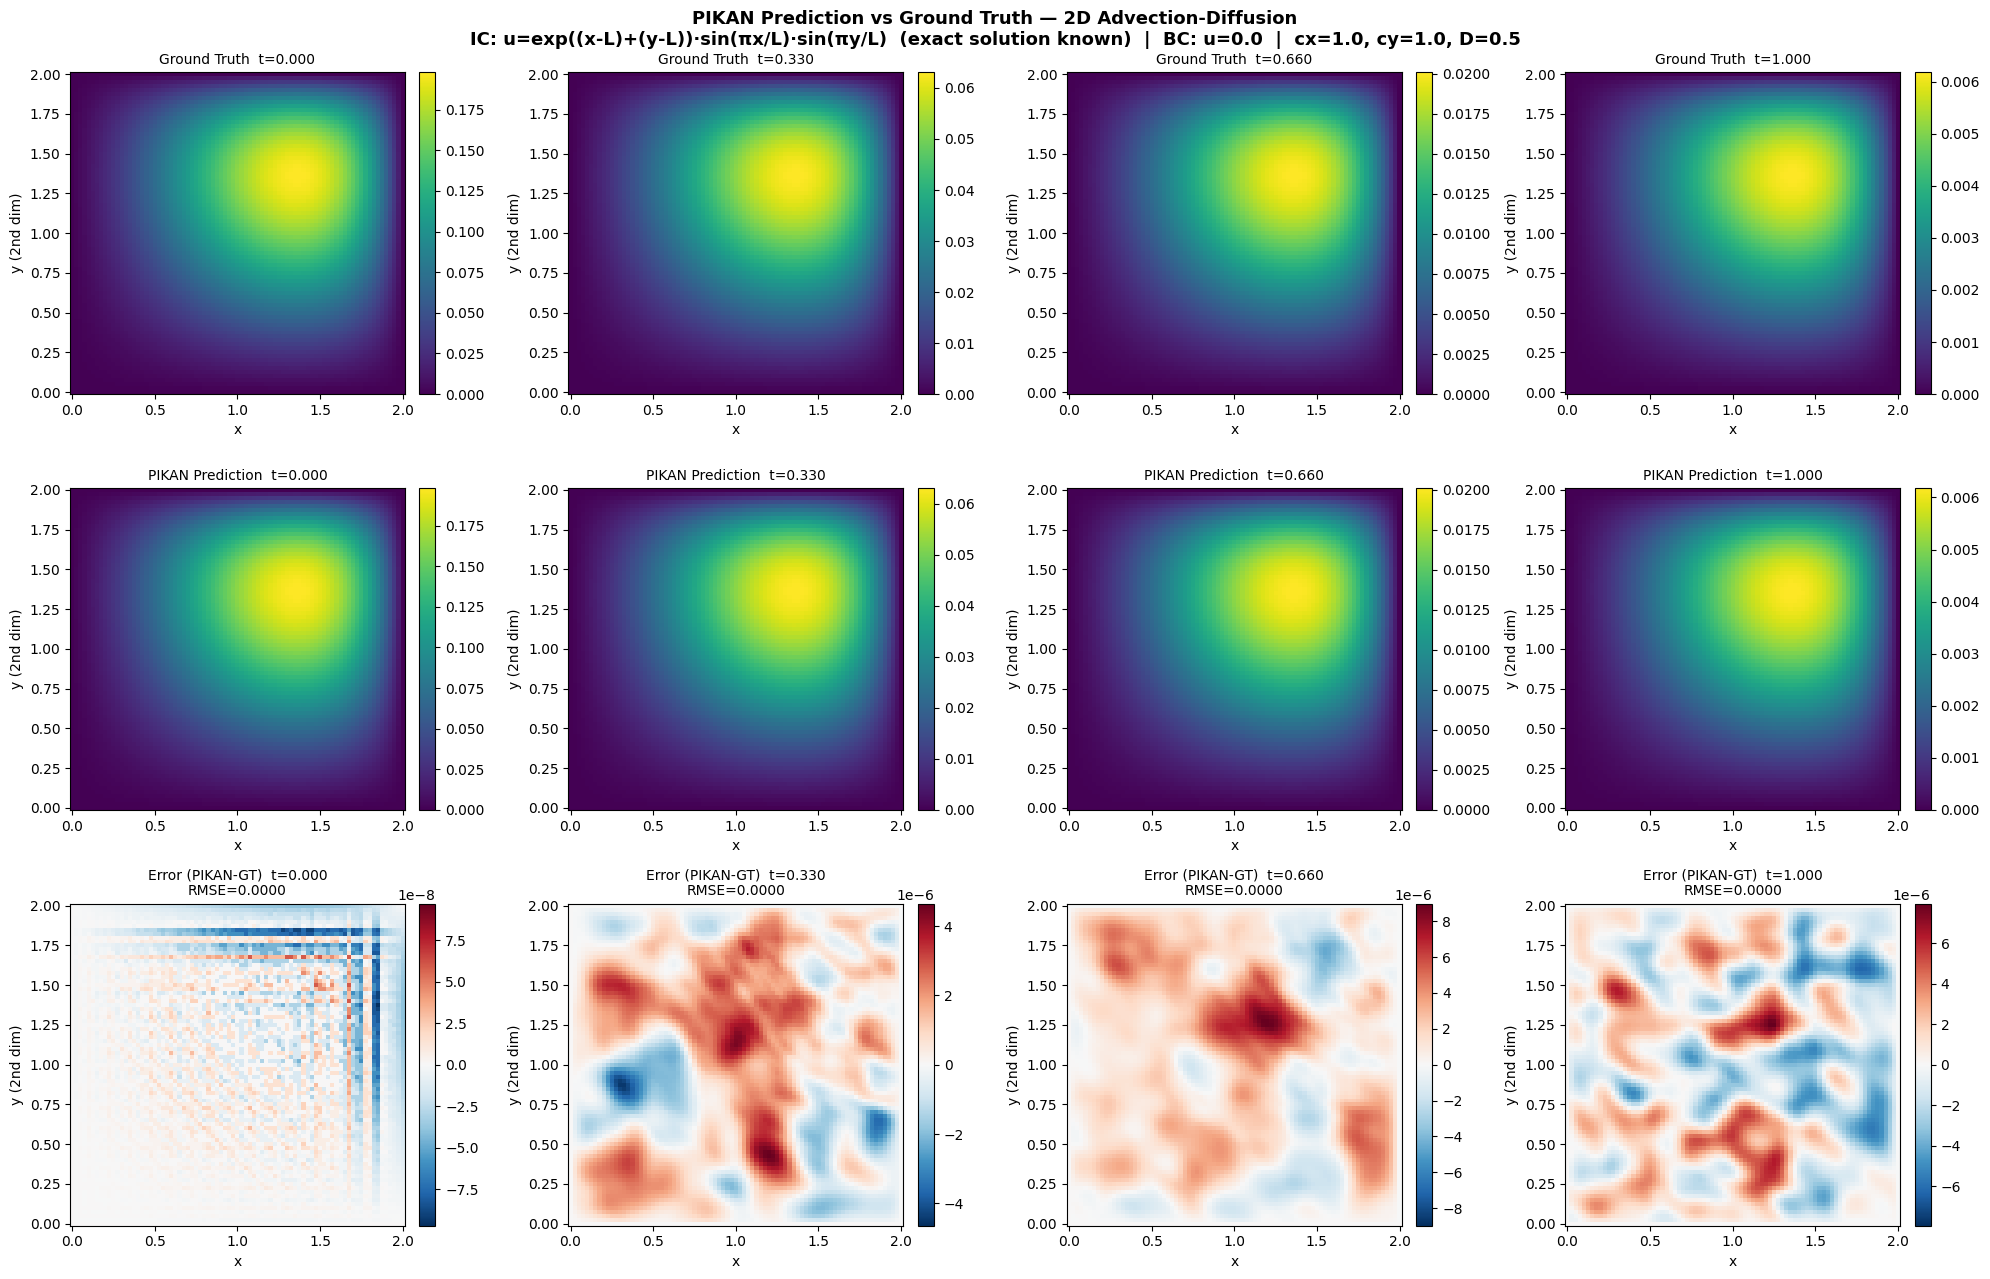

  -> saved PIKAN_02_snapshot_comparison.png


In [26]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'PIKAN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=exp((x-L)+(y-L))\u00b7sin(\u03c0x/L)\u00b7sin(\u03c0y/L)  (exact solution known)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Upk   = PIKAN_pred_snaps[si]
    err   = Upk - Ugt
    vmin  = min(Ugt.min(), Upk.min()); vmax = max(Ugt.max(), Upk.max())
    emax  = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Upk.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'PIKAN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_pk = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (PIKAN-GT)  t={tk:.3f}\nRMSE={rmse_pk:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('PIKAN_02_snapshot_comparison.png')

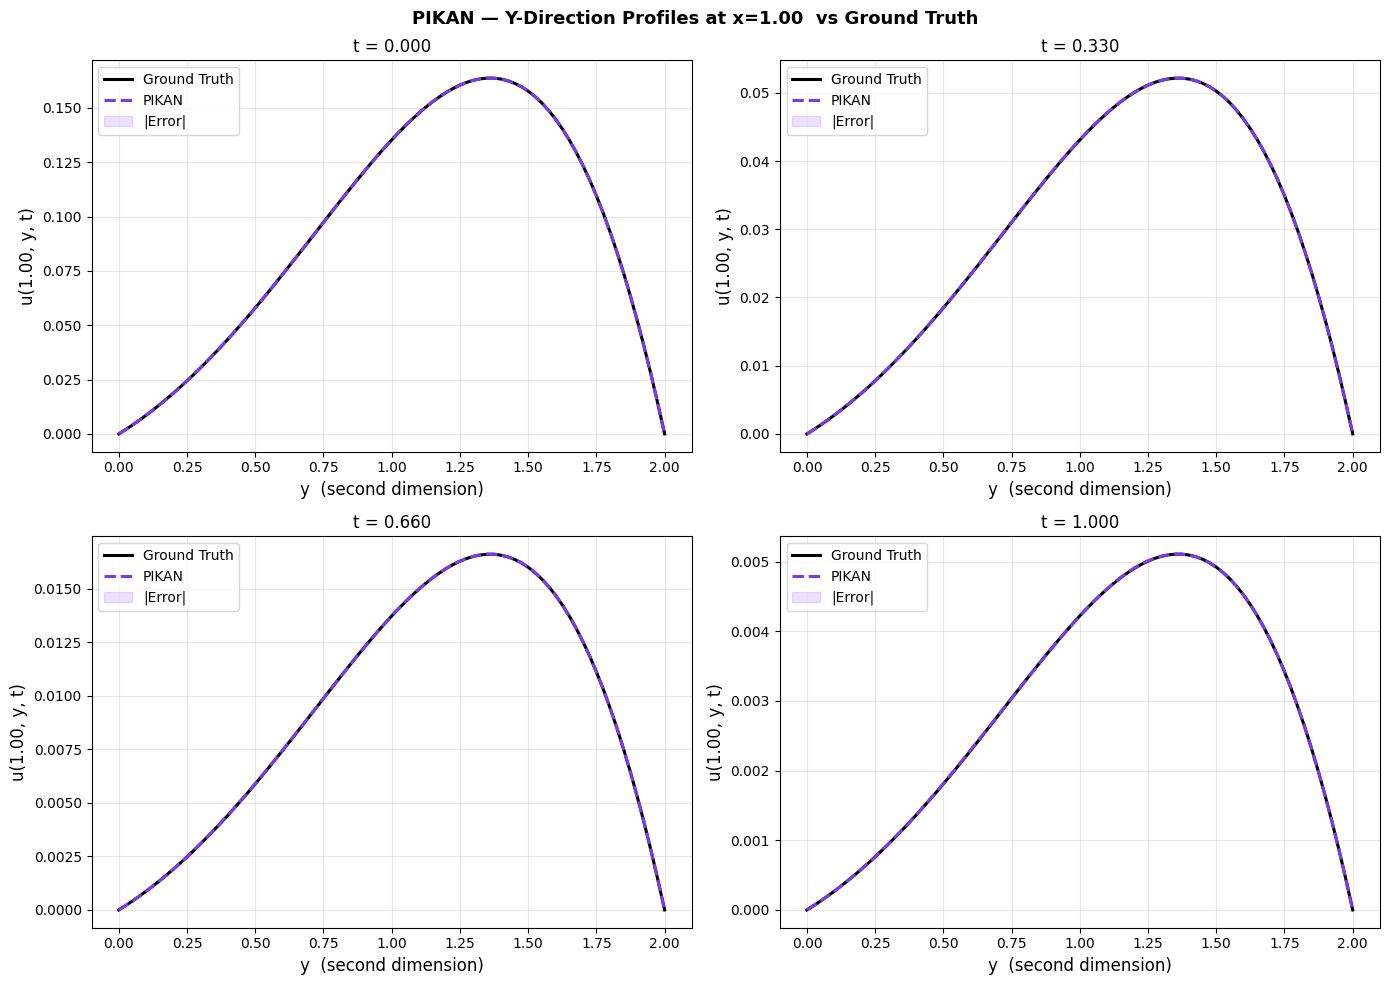

  -> saved PIKAN_03_y_profiles.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'PIKAN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    pk_y = PIKAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, pk_y, color='#7C3AED', ls='--', lw=2.2, label='PIKAN')
    ax.fill_between(y_grid, gt_y, pk_y, alpha=0.15, color='#7C3AED', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('PIKAN_03_y_profiles.png')

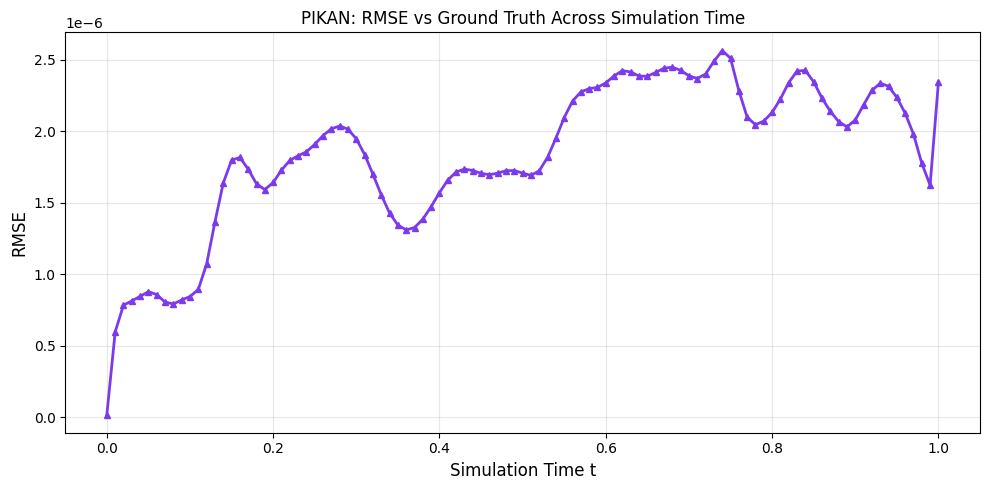

  -> saved PIKAN_04_rmse_over_time.png


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, pikan_rmse_t, '^-', color='#7C3AED', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('PIKAN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('PIKAN_04_rmse_over_time.png')

## 16. KAN vs PINN vs PIKAN — Comparative Analysis

  [ckpt] loaded <- kan_done.pt
  [ckpt] loaded <- pinn_done.pt
  [ckpt] loaded <- pikan_done.pt
All models and training histories restored for comparison plots.


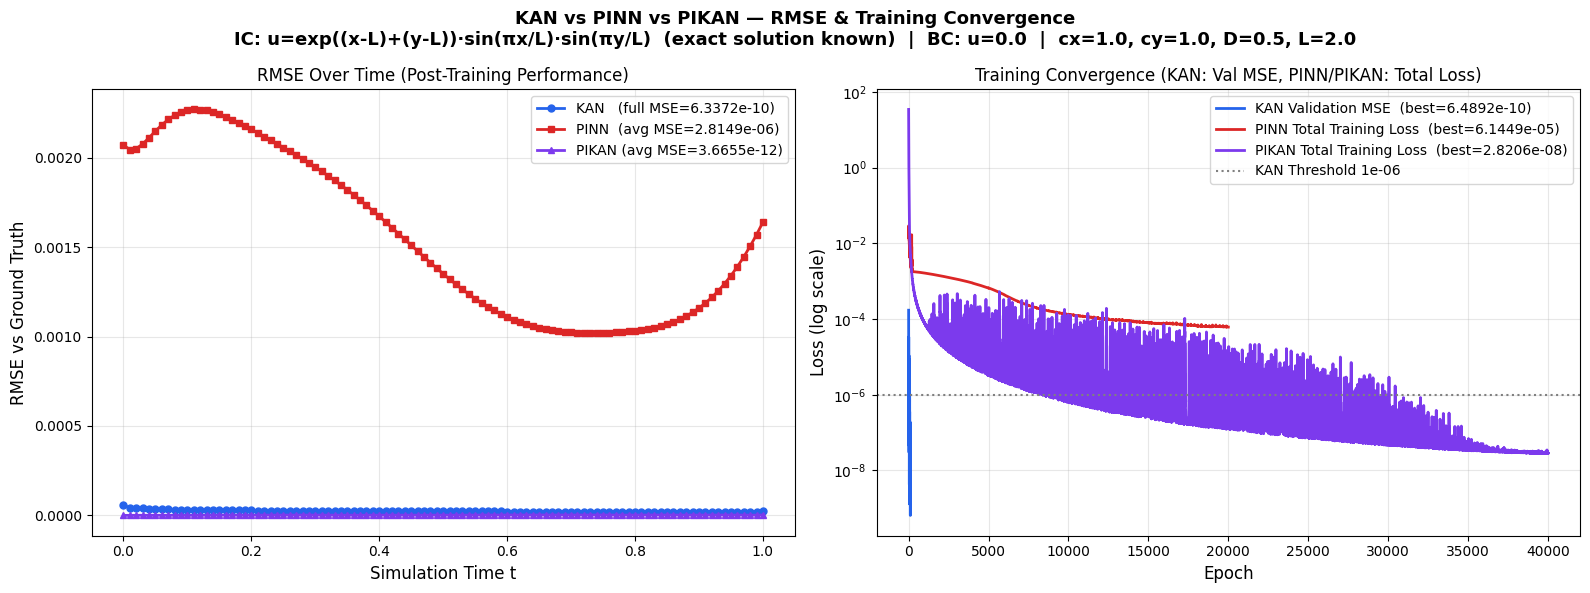

  -> saved COMPARE_01_rmse_and_convergence.png


In [29]:
kan_model.to(device)
pinn_model.to(device)

_kan_done = load_ckpt('kan_done')
if _kan_done is not None:
    kan_val_losses   = _kan_done['val_losses']
    kan_train_losses = _kan_done['train_losses']
    kan_lr_history   = _kan_done['lr_history']

_pinn_done = load_ckpt('pinn_done')
if _pinn_done is not None:
    pinn_loss_hist  = _pinn_done['loss_hist']
    lbfgs_loss_hist = _pinn_done['lbfgs_loss_hist']

_pikan_done = load_ckpt('pikan_done')
if _pikan_done is not None:
    pikan_loss_hist_np = _pikan_done['loss_hist'] # Ensure it's numpy array


print('All models and training histories restored for comparison plots.')

compare_snaps  = [len(snap_t) // 2, len(snap_t) - 1]
compare_labels = ['t = T/2', 't = T']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'KAN vs PINN vs PIKAN — RMSE & Training Convergence\n'
    f'IC: u=exp((x-L)+(y-L))\u00b7sin(\u03c0x/L)\u00b7sin(\u03c0y/L)  (exact solution known)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}, L={L}',
    fontsize=13, fontweight='bold'
)

ax = axes[0]
ax.plot(snap_t, kan_rmse_t,   'o-', color='#2563EB', lw=2, ms=5, label=f'KAN   (full MSE={kan_mse_full:.4e})')
ax.plot(snap_t, pinn_rmse_t,  's-', color='#DC2626', lw=2, ms=5, label=f'PINN  (avg MSE={np.mean(pinn_mse_eval):.4e})')
ax.plot(snap_t, pikan_rmse_t, '^-', color='#7C3AED', lw=2, ms=5, label=f'PIKAN (avg MSE={np.mean(pikan_mse_eval):.4e})')
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE vs Ground Truth', fontsize=FS)
ax.set_title('RMSE Over Time (Post-Training Performance)', fontsize=FS) # Clarify title
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
# Use ep_a_kan, ep_a_pinn, ep_a_pikan for x-axis as defined in previous plotting cells
ep_a_kan = np.arange(1, len(kan_val_losses) + 1)
ep_a_pinn = np.arange(1, len(pinn_loss_hist) + 1)
ep_a_pikan = np.arange(1, len(pikan_loss_hist_np) + 1)

ax.semilogy(ep_a_kan, kan_val_losses,
            lw=2, color='#2563EB', label=f'KAN Validation MSE  (best={kan_best_val:.4e})') # Clarify label
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 0],
            lw=2, color='#DC2626', label=f'PINN Total Training Loss  (best={pinn_best_loss:.4e})') # Clarify label
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 0],
            lw=2, color='#7C3AED', label=f'PIKAN Total Training Loss  (best={pikan_best_loss:.4e})') # Clarify label
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.5, label=f'KAN Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Loss (log scale)', fontsize=FS)
ax.set_title('Training Convergence (KAN: Val MSE, PINN/PIKAN: Total Loss)', fontsize=FS) # Clarify title
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_01_rmse_and_convergence.png')

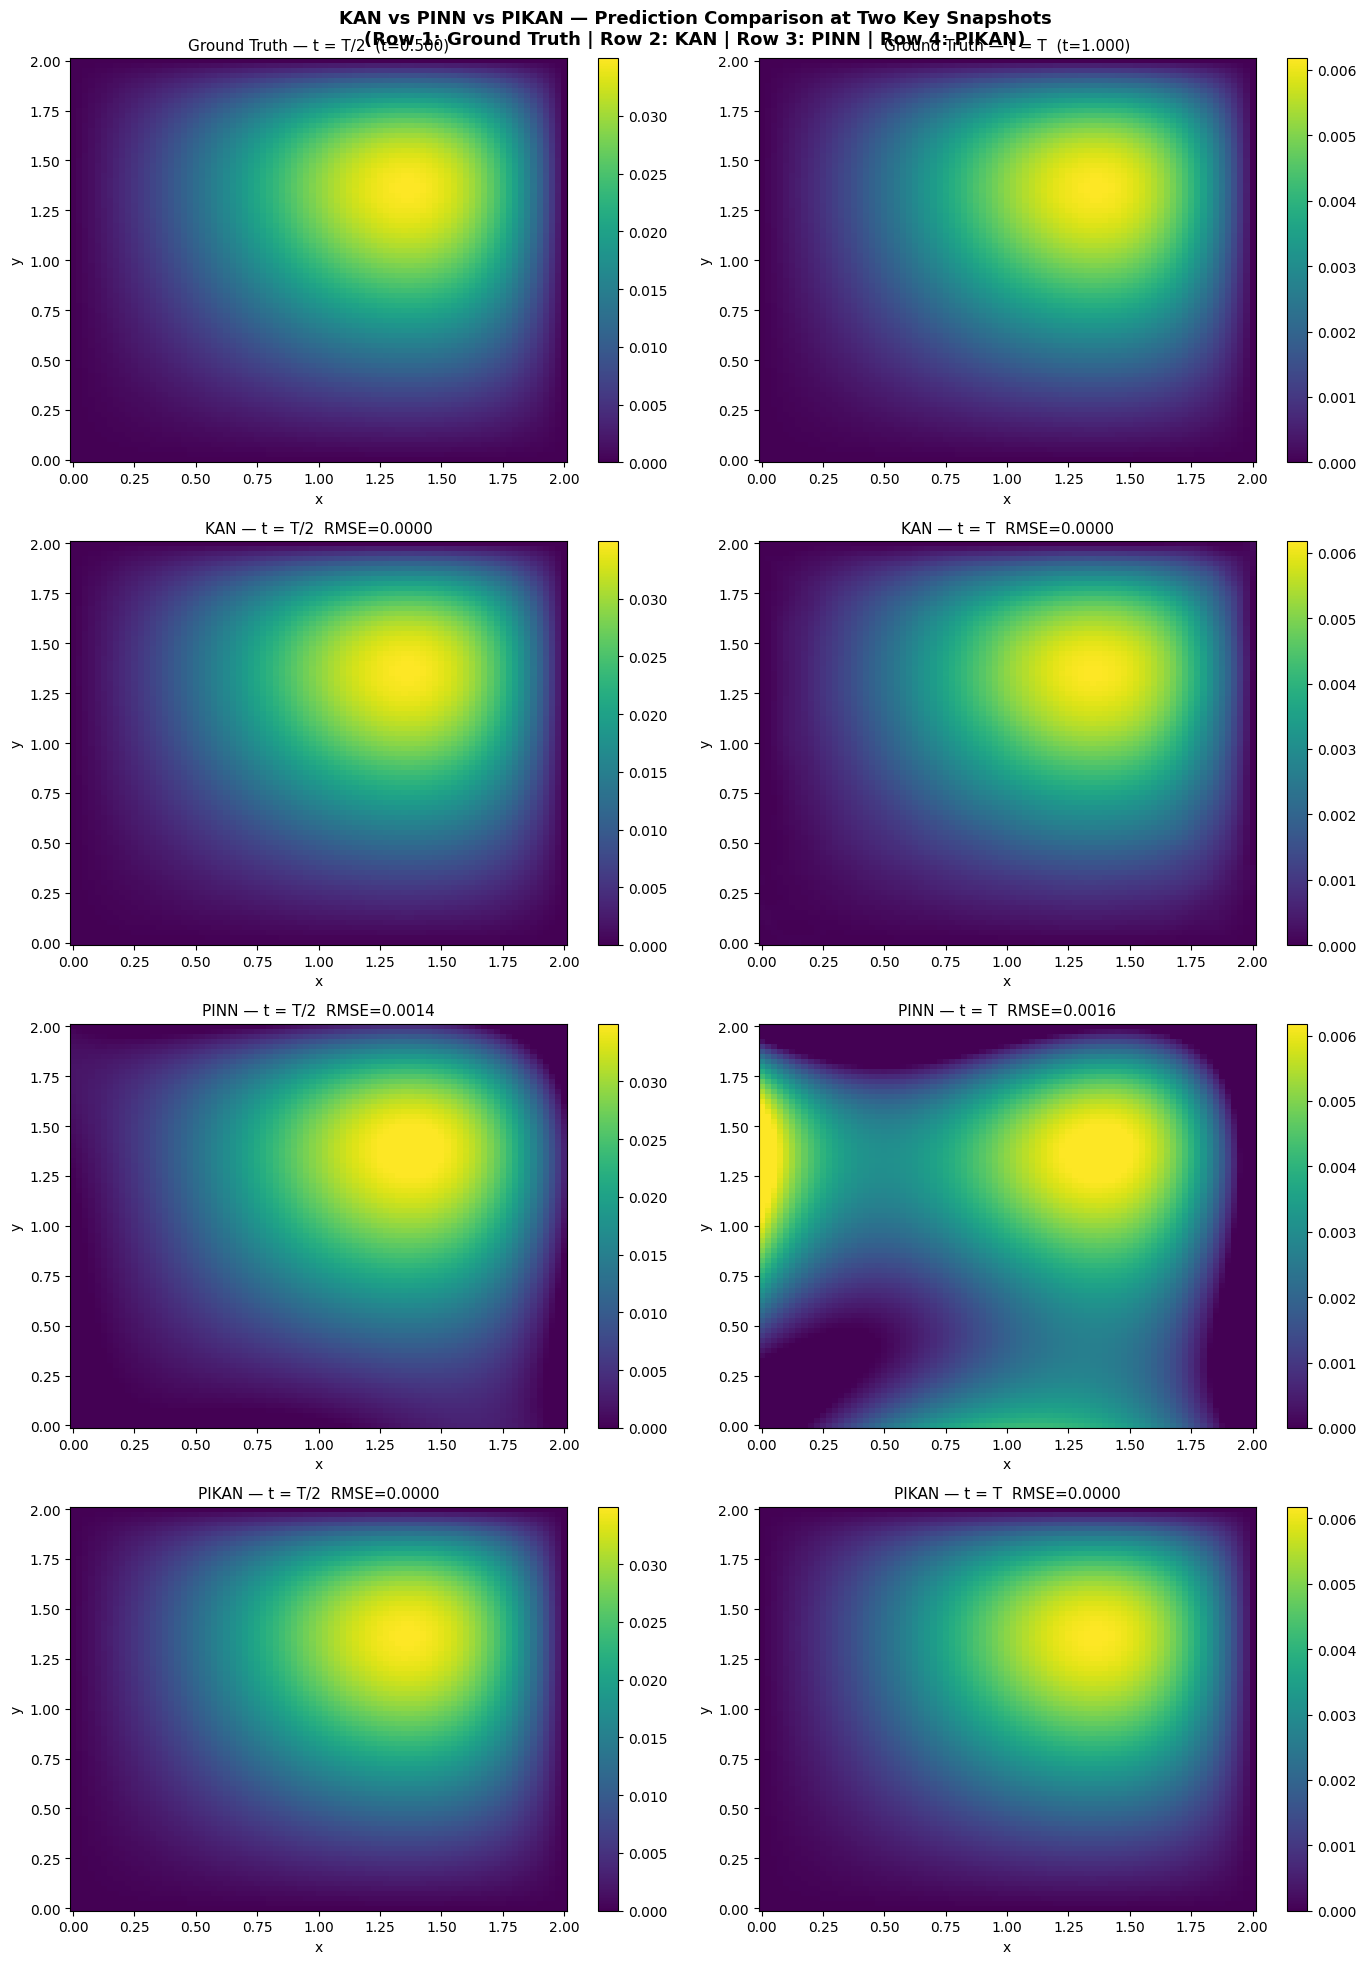

  -> saved COMPARE_02_side_by_side_predictions.png


In [30]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle(
    'KAN vs PINN vs PIKAN — Prediction Comparison at Two Key Snapshots\n'
    '(Row 1: Ground Truth | Row 2: KAN | Row 3: PINN | Row 4: PIKAN)',
    fontsize=13, fontweight='bold'
)

for col, (si, label) in enumerate(zip(compare_snaps, compare_labels)):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Ukn   = KAN_pred_snaps[si]
    Upinn = PINN_pred_snaps[si]
    Upk   = PIKAN_pred_snaps[si]
    vmin  = Ugt.min(); vmax = Ugt.max()

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth — {label}  (t={tk:.3f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_k = np.sqrt(np.mean((Ukn - Ugt)**2))
    ax.set_title(f'KAN — {label}  RMSE={rmse_k:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, Upinn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_p = np.sqrt(np.mean((Upinn - Ugt)**2))
    ax.set_title(f'PINN — {label}  RMSE={rmse_p:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[3, col]
    im = ax.pcolormesh(x_grid, y_grid, Upk.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_pk = np.sqrt(np.mean((Upk - Ugt)**2))
    ax.set_title(f'PIKAN — {label}  RMSE={rmse_pk:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_02_side_by_side_predictions.png')

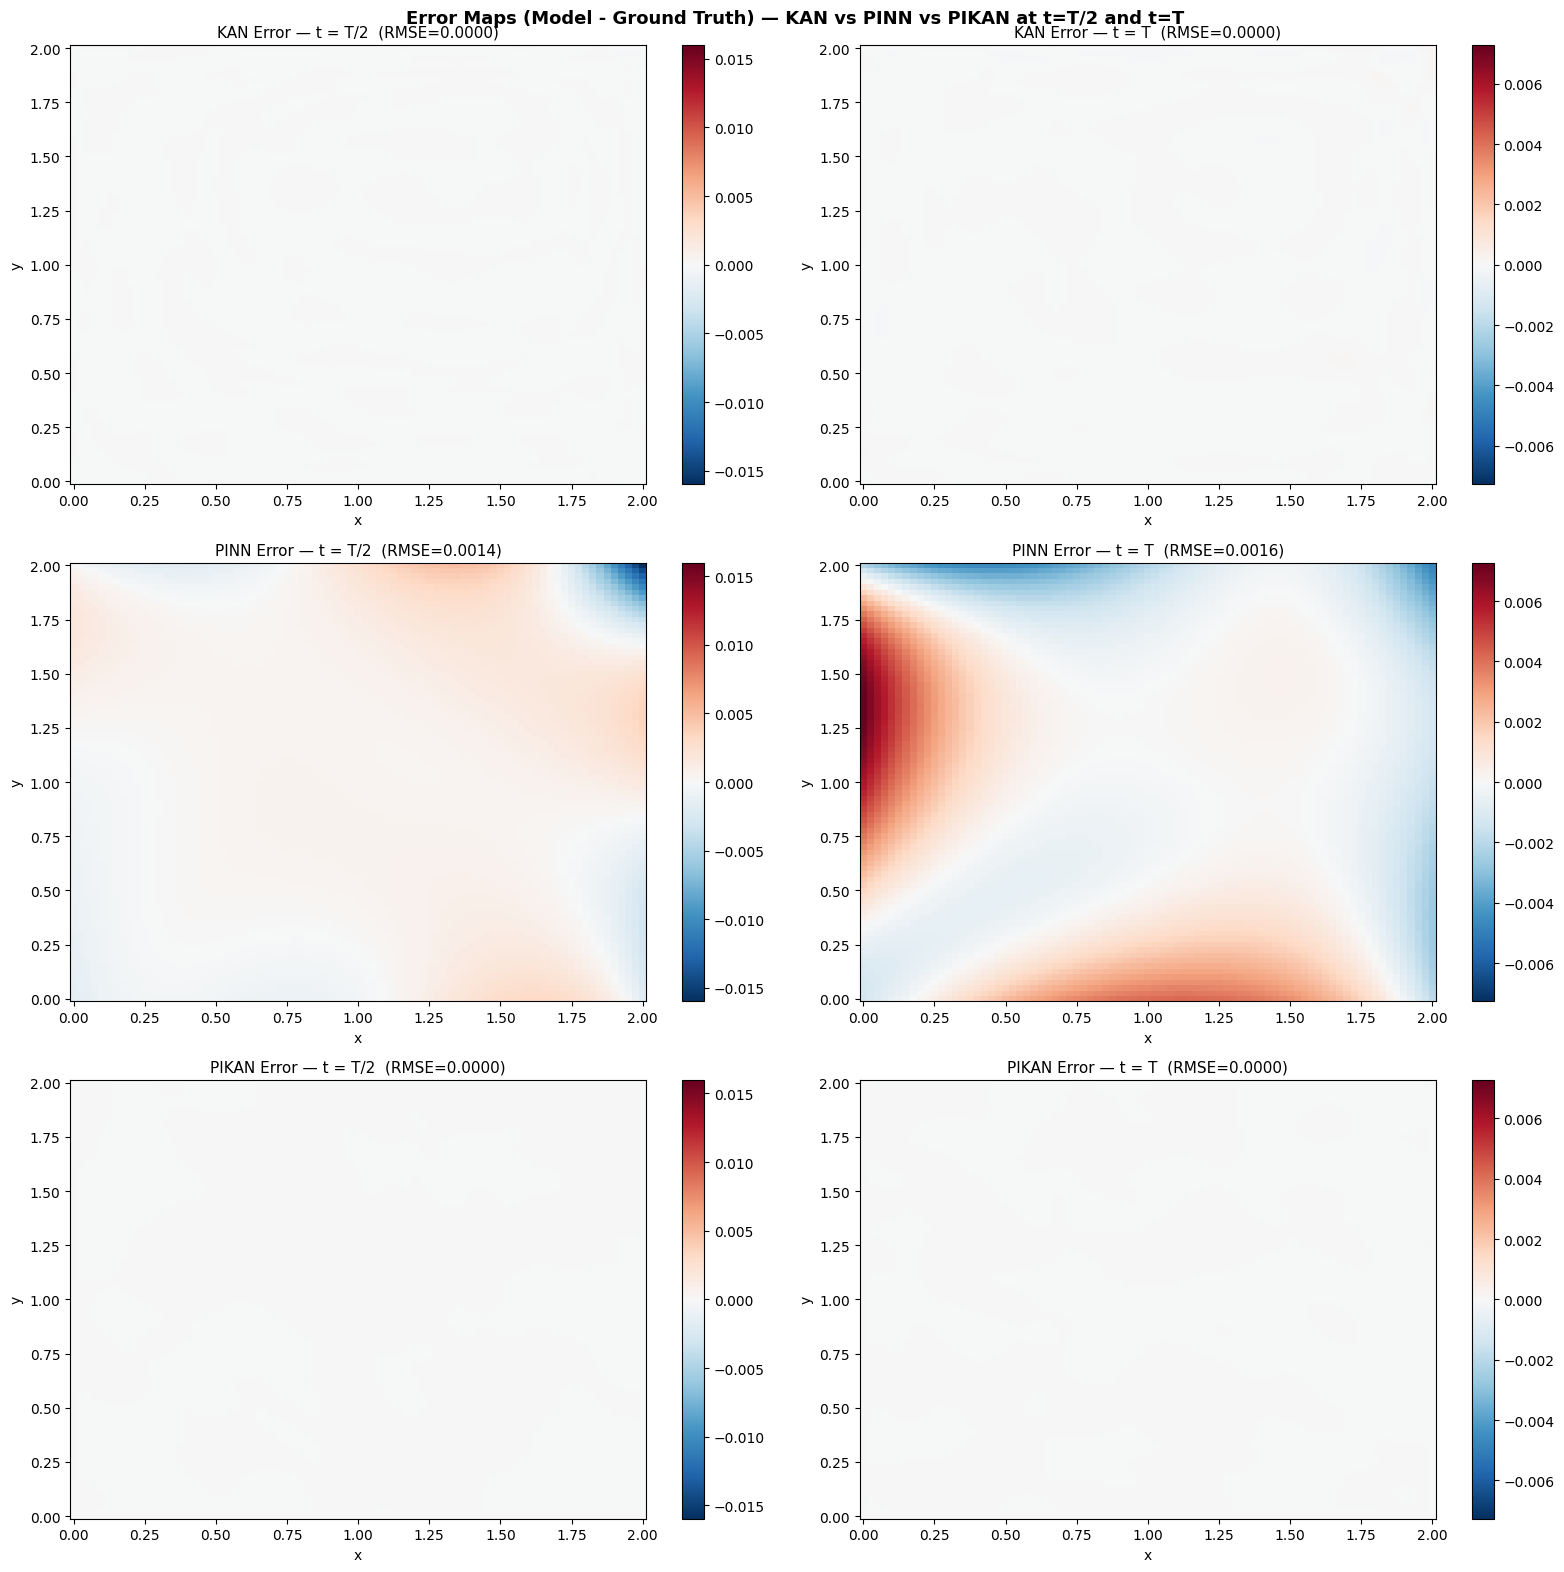

  -> saved COMPARE_03_error_maps.png


In [31]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Error Maps (Model - Ground Truth) — KAN vs PINN vs PIKAN at t=T/2 and t=T',
             fontsize=13, fontweight='bold')

for col, (si, label) in enumerate(zip(compare_snaps, compare_labels)):
    Ugt   = KAN_true_snaps[si]
    err_k = KAN_pred_snaps[si]  - Ugt
    err_p = PINN_pred_snaps[si] - Ugt
    err_pk= PIKAN_pred_snaps[si]- Ugt
    emax  = max(abs(err_k).max(), abs(err_p).max(), abs(err_pk).max()) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, err_k.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'KAN Error — {label}  (RMSE={np.sqrt(np.mean(err_k**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, err_p.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'PINN Error — {label}  (RMSE={np.sqrt(np.mean(err_p**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err_pk.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'PIKAN Error — {label}  (RMSE={np.sqrt(np.mean(err_pk**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_03_error_maps.png')

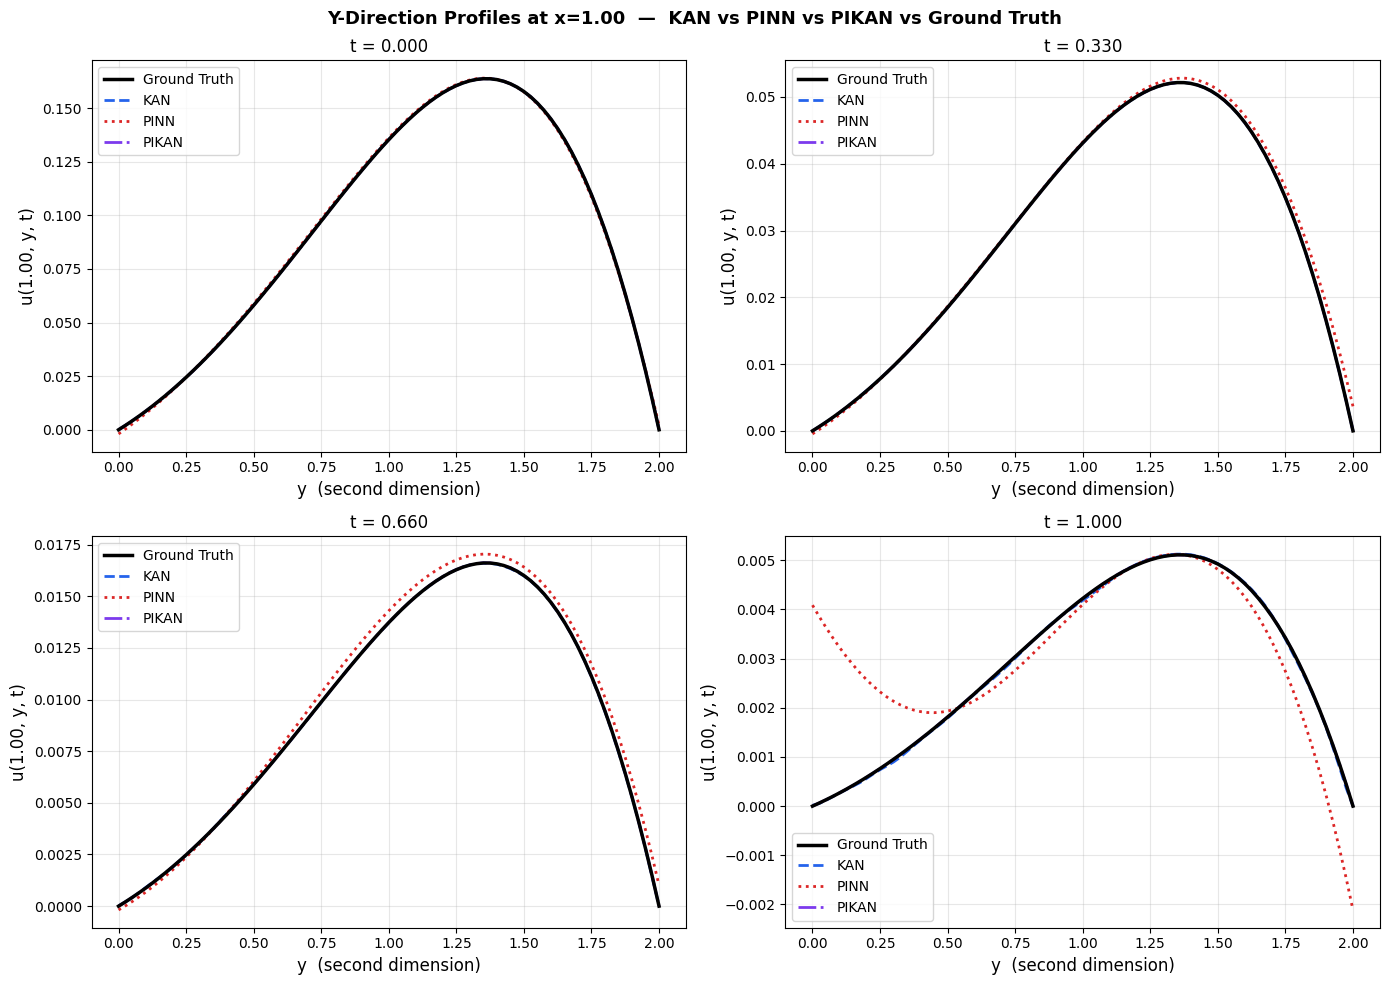

  -> saved COMPARE_04_y_profiles.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  —  KAN vs PINN vs PIKAN vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si,   ix_mid, :]
    kn_y = KAN_pred_snaps[si,   ix_mid, :]
    pn_y = PINN_pred_snaps[si,  ix_mid, :]
    pk_y = PIKAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',                    lw=2.5, label='Ground Truth', zorder=4)
    ax.plot(y_grid, kn_y, color='#2563EB', ls='--', lw=2.0, label='KAN')
    ax.plot(y_grid, pn_y, color='#DC2626', ls=':',  lw=2.0, label='PINN')
    ax.plot(y_grid, pk_y, color='#7C3AED', ls='-.',  lw=2.0, label='PIKAN')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_04_y_profiles.png')

## 17. Final Summary

## 17. Comparison against the exact solution


In [33]:
# All models vs the EXACT solution.
#  (a) on the held-out snapshots (grid points; KAN and PIKAN never trained on these times)
#  (b) on 200k random (x, y, t) points off the grid, compared with the closed-form formula
# The ADI finite-difference solver is included as a classical-method reference.
def _rl2(P, G):
    return float(np.linalg.norm((P - G).ravel()) / (np.linalg.norm(G.ravel()) + 1e-12))

ADI_snaps = C_adi[snap_idx_list].transpose(0, 2, 1)          # (snap, x, y) like the others
_ho_t  = snap_t[holdout_snaps]
_early = holdout_snaps[_ho_t <  0.25]
_late  = holdout_snaps[_ho_t >= 0.25]

# (b) random off-grid points
_rng = np.random.default_rng(7)
_n   = 200_000
_xr, _yr, _tr = _rng.random(_n) * L, _rng.random(_n) * L, _rng.random(_n) * T
_ur  = exact_solution(_xr, _yr, _tr)
_xn, _yn, _tn = normalise_inputs(_xr, _yr, _tr)
_in_xyt = torch.tensor(np.stack([_xn, _yn, _tn], 1), dtype=torch.float32)   # KAN order
_in_txy = torch.tensor(np.stack([_tn, _xn, _yn], 1), dtype=torch.float32)   # PINN / PIKAN order

@torch.no_grad()
def _pred(model, X, chunk=32768):
    model.eval()
    return np.concatenate([model(X[i:i + chunk].to(device)).cpu().numpy().ravel()
                           for i in range(0, len(X), chunk)])

rows = []
for name, P, model, Xin in [('KAN',   KAN_pred_snaps,   kan_model,   _in_xyt),
                            ('PINN',  PINN_pred_snaps,  pinn_model,  _in_txy),
                            ('PIKAN', PIKAN_pred_snaps, pikan_model, _in_txy),
                            (f'ADI N={Nx*GT_REFINE}', ADI_snaps, None, None)]:
    ho_all = _rl2(P[holdout_snaps], KAN_true_snaps[holdout_snaps])
    ho_e   = _rl2(P[_early], KAN_true_snaps[_early])
    ho_l   = _rl2(P[_late],  KAN_true_snaps[_late])
    rnd    = _rl2(_pred(model, Xin), _ur) if model is not None else float('nan')
    rows.append((name, ho_all, ho_e, ho_l, rnd))

print(f'Error vs EXACT solution (relative L2). Held-out snapshots: {len(holdout_snaps)} '
      f'(t < 0.25: {len(_early)}, t >= 0.25: {len(_late)});  random off-grid points: {_n:,}\n')
print(f'  {"model":11s} | {"held-out":>9s} | {"t < 0.25":>9s} | {"t >= 0.25":>9s} | {"random pts":>10s}')
print('  ' + '-' * 60)
for name, a, e, l, r in rows:
    rs = f'{r:10.3e}' if np.isfinite(r) else f'{"(grid only)":>10s}'
    print(f'  {name:11s} | {a:9.3e} | {e:9.3e} | {l:9.3e} | {rs}')
print('\nNote: the KAN (and PIKAN if PIKAN_USE_DATA=True) trained on the other 81 snapshots of the exact solution;'
      '\nPINN and PIKAN (default) used only the PDE, IC and BC.')


Error vs EXACT solution (relative L2). Held-out snapshots: 20 (t < 0.25: 5, t >= 0.25: 15);  random off-grid points: 200,000

  model       |  held-out |  t < 0.25 | t >= 0.25 | random pts
  ------------------------------------------------------------
  KAN         | 7.533e-04 | 5.459e-04 | 1.353e-03 |  1.475e-03
  PINN        | 4.868e-02 | 3.605e-02 | 8.595e-02 |  4.498e-02
  PIKAN       | 5.729e-05 | 2.178e-05 | 1.282e-04 |  5.815e-05
  ADI N=320   | 2.444e-04 | 1.307e-04 | 5.094e-04 | (grid only)

Note: the KAN (and PIKAN if PIKAN_USE_DATA=True) trained on the other 81 snapshots of the exact solution;
PINN and PIKAN (default) used only the PDE, IC and BC.


In [34]:
print('\n' + '=' * 70)
print('  FINAL SUMMARY — KAN, PINN & PIKAN on 2D Advection-Diffusion PDE')
print('=' * 70)
print(f'  PDE       : du/dt + {CX}*du/dx + {CY}*du/dy = {D}*(d2u/dx2 + d2u/dy2)')
print(f'  IC        : u(x,y,0) = exp({A_X:g}(x-L)+{A_Y:g}(y-L)) sin({M_X}pi x/L) sin({M_Y}pi y/L)')
print(f'  Exact     : u = u(x,y,0) * exp({LAMBDA:.4f} t)   (ground truth for all models)')
print(f'  BC        : u = {BC_VAL} on all boundaries (Dirichlet)')
print(f'  Domain    : x,y in [0,{L}],  t in [0,{T}]')
print(f'  Grid      : Nx=Ny={Nx}, Dx=Dy={DX:.4f}, Dt={DT}')
print(f'  Baseline  : ADI-Crank-Nicolson on {Nx*GT_REFINE}^2 grid, dt={DT/GT_REFINE:g}, '
      f'relL2 vs exact at t=T: {_rel(C_adi[-1], C_gt[-1]):.2e}')
print(f'  Inputs    : normalised to [-1, 1] for all models')
print()
print(f'  ── KAN ──────────────────────────────────────────────────────')
print(f'  Architecture  : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}')
print(f'  Parameters    : {kan_n_params:,}')
print(f'  Training      : Supervised regression on {len(snap_t) - len(holdout_snaps)} GT snapshots ({len(holdout_snaps)} held out)')
print(f'  Optimiser     : AdamW + ReduceLROnPlateau')
print(f'  Stop reason   : {kan_stop_reason}')
print(f'  Epochs run    : {kan_final_epoch}')
print(f'  Best val MSE  : {kan_best_val:.6f}')
print(f'  Full MSE      : {kan_mse_full:.6f}')
print(f'  RMSE          : {kan_rmse_all:.6f}')
print(f'  Rel. L1 err   : {kan_rel_err*100:.2f} %')
print(f'  Training time : {kan_total_time:.1f}s ({kan_total_time/60:.1f} min)')
print()
print(f'  ── PINN ─────────────────────────────────────────────────────')
print(f'  Architecture  : MLP  width=128  depth=6')
print(f'  Parameters    : {pinn_n_params:,}')
print(f'  Training      : Physics-informed (PDE residual + IC + BC losses)')
print(f'  Loss weights  : w_f={PINN_W_F}, w_ic={PINN_W_IC}, w_bc={PINN_W_BC}')
print(f'  Optimiser     : Adam ({pinn_adam_epochs} epochs) + L-BFGS ({len(lbfgs_loss_hist)} steps)')
print(f'  Stop reason   : {pinn_stop_reason}')
print(f'  Adam epochs   : {pinn_adam_epochs}')
print(f'  L-BFGS steps  : {len(lbfgs_loss_hist)}')
print(f'  Best loss     : {pinn_best_loss:.6f}')
print(f'  Avg MSE (eval): {np.mean(pinn_mse_eval):.6f}')
print(f'  Training time : {pinn_total_time:.1f}s ({pinn_total_time/60:.1f} min)')
print()
print(f'  ── PIKAN ────────────────────────────────────────────────────')
print(f'  Architecture  : KAN[3,32,32,32,1]  grid=8  order=3')
print(f'  Parameters    : {pikan_n_params:,}')
print(f'  Training      : {"data + " if PIKAN_USE_DATA else ""}PDE'
      f'{" (IC and BC built in exactly)" if PIKAN_HARD else " + IC + BC"}')
print(f'  Loss weights  : adaptive (final) ' + ', '.join(f'{k}={lam[k]:.2e}' for k in active_terms()))
print(f'  Optimiser     : Adam ({pikan_final_epoch} steps) + L-BFGS ({len(pikan_lbfgs_hist)} steps)')
print(f'  Stop reason   : {pikan_stop_reason}')
print(f'  Held-out relL2: {pikan_best_val:.3e}  (snapshots never used in training)')
print(f'  L-BFGS steps  : {len(pikan_lbfgs_hist)}')
print(f'  Best loss     : {pikan_best_loss:.6f}')
print(f'  Avg MSE (eval): {np.mean(pikan_mse_eval):.6f}')
print(f'  Training time : {pikan_total_time:.1f}s ({pikan_total_time/60:.1f} min)')
print()
print(f'  All plots saved to: {OUT_DIR}/')
print('=' * 70)


  FINAL SUMMARY — KAN, PINN & PIKAN on 2D Advection-Diffusion PDE
  PDE       : du/dt + 1.0*du/dx + 1.0*du/dy = 0.5*(d2u/dx2 + d2u/dy2)
  IC        : u(x,y,0) = exp(1(x-L)+1(y-L)) sin(1pi x/L) sin(1pi y/L)
  Exact     : u = u(x,y,0) * exp(-3.4674 t)   (ground truth for all models)
  BC        : u = 0.0 on all boundaries (Dirichlet)
  Domain    : x,y in [0,2.0],  t in [0,1.0]
  Grid      : Nx=Ny=80, Dx=Dy=0.0250, Dt=0.002
  Baseline  : ADI-Crank-Nicolson on 320^2 grid, dt=0.0005, relL2 vs exact at t=T: 1.41e-03
  Inputs    : normalised to [-1, 1] for all models

  ── KAN ──────────────────────────────────────────────────────
  Architecture  : [3, 32, 32, 32, 1]  grid=8  order=3
  Parameters    : 26,304
  Training      : Supervised regression on 81 GT snapshots (20 held out)
  Optimiser     : AdamW + ReduceLROnPlateau
  Stop reason   : convergence
  Epochs run    : 116
  Best val MSE  : 0.000000
  Full MSE      : 0.000000
  RMSE          : 0.000025
  Rel. L1 err   : 0.10 %
  Training ti